# Data Import from GitHub-Repo

In [3]:
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.stattools import adfuller

# The base URL for RAW content on your GitHub branch
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/"

# Define your categories based on your repo structure
FILE_CATEGORIES = {
    'Indices': [
        'sp500_close_clean.csv',
        'bovespa_close_clean.csv',
        'eurostoxx50_close_clean.csv',
        'ftse100_close_clean.csv',
        'jse40_close_clean.csv',
        'nikkei225_close_clean.csv',
        'asx50_close_clean.csv'
    ],
    'Macro': ['macro_full.csv']
}

all_assets = pd.DataFrame()

# ─── 2. Fetch and Merge Data ──────────────────────────────────────────────
for cat, files in FILE_CATEGORIES.items():
    for f in files:
        url = GITHUB_RAW_BASE + f
        try:
            # Directly read from URL
            df = pd.read_csv(url, index_col=0, parse_dates=True)

            if cat == 'Indices':
                # Create a mean index value for the class comparison
                name = f.split('_')[0].upper()
                all_assets[name] = df.mean(axis=1)
            else:
                # Merge all macro factors (Yields, FX, Risk)
                all_assets = pd.concat([all_assets, df], axis=1)

            print(f"✅ Successfully loaded: {f}")
        except Exception as e:
            print(f"❌ Failed to load {f}: {e}")

# Apply your study time horizon
all_assets = all_assets.loc['2014-01-01':'2025-12-31'].ffill().dropna()

✅ Successfully loaded: sp500_close_clean.csv
✅ Successfully loaded: bovespa_close_clean.csv
✅ Successfully loaded: eurostoxx50_close_clean.csv
✅ Successfully loaded: ftse100_close_clean.csv
✅ Successfully loaded: jse40_close_clean.csv
✅ Successfully loaded: nikkei225_close_clean.csv
✅ Successfully loaded: asx50_close_clean.csv
✅ Successfully loaded: macro_full.csv


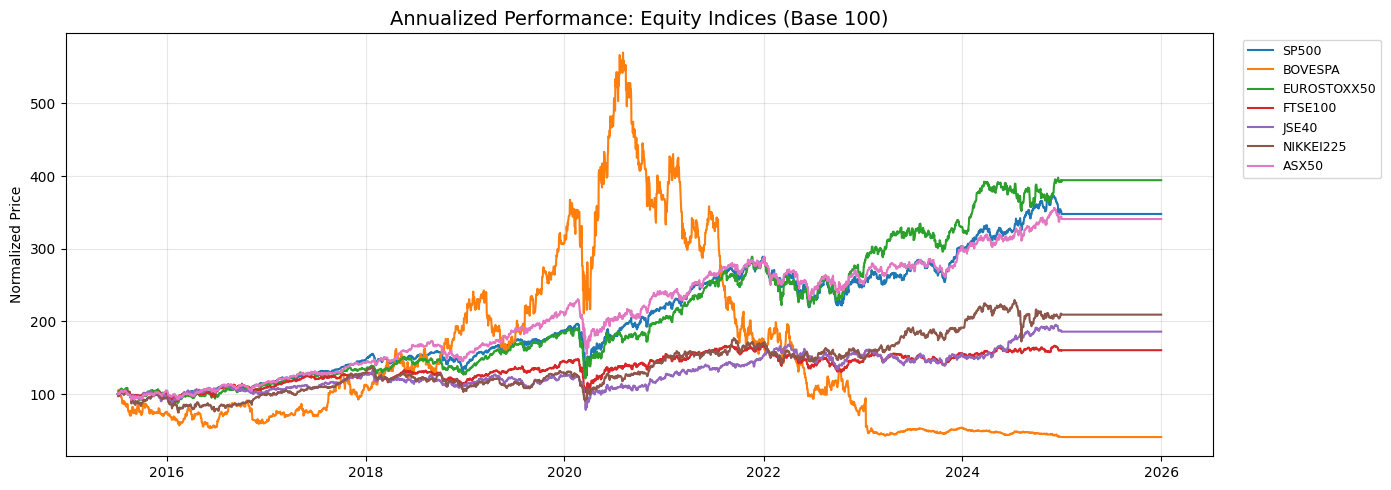

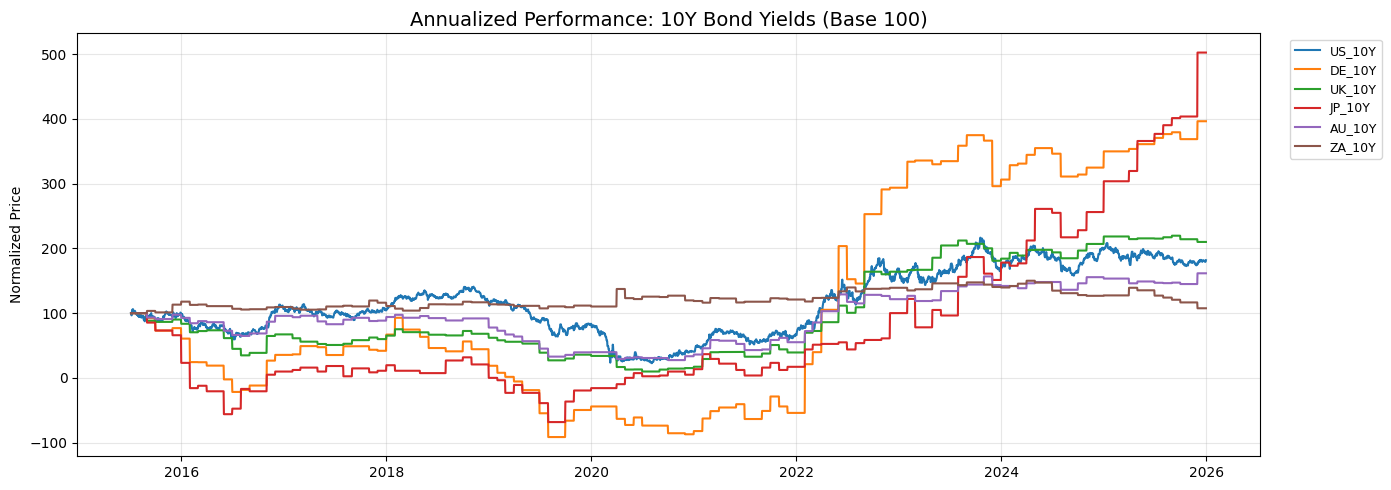

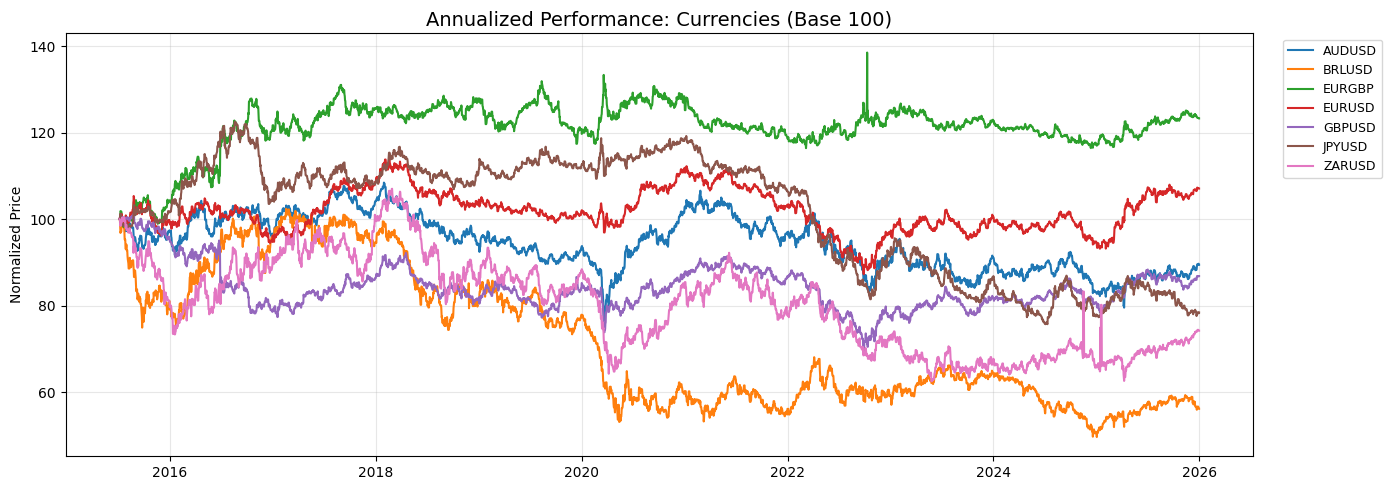

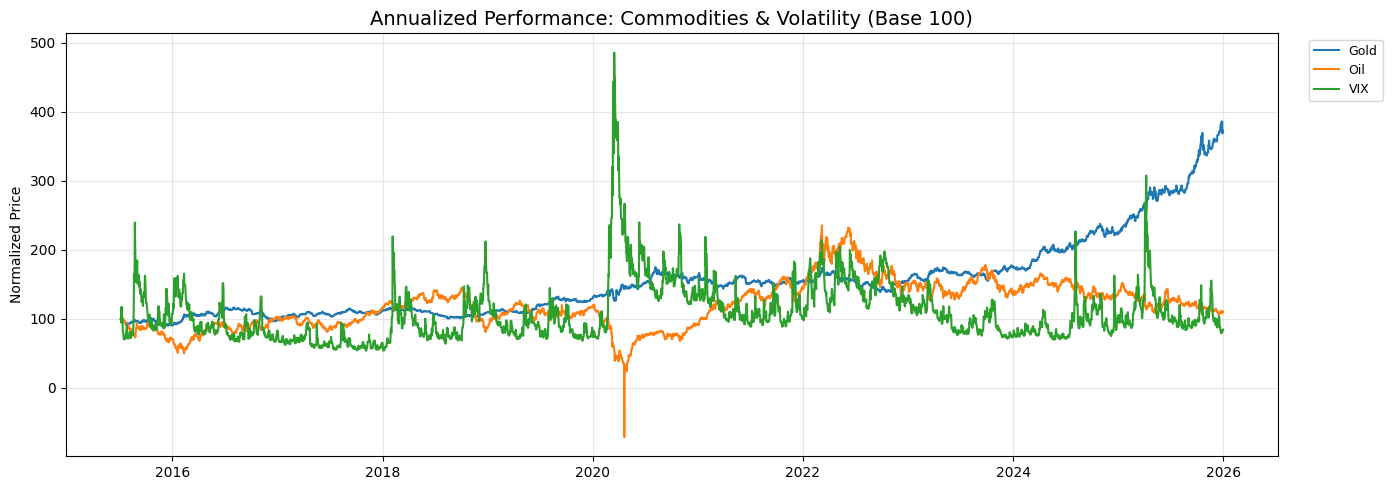

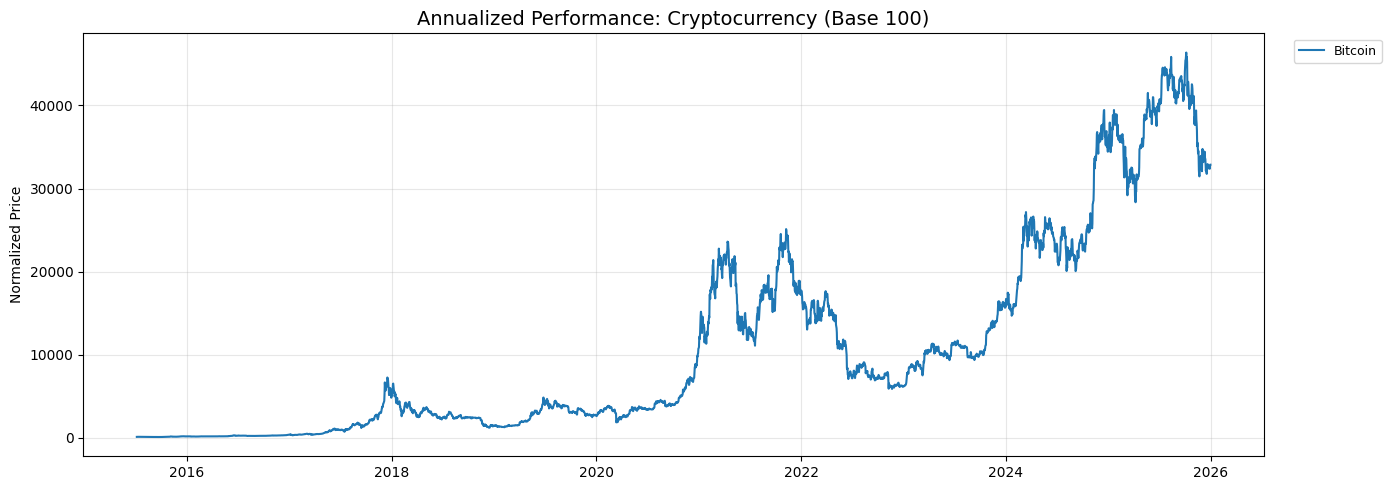

In [5]:
import matplotlib.pyplot as plt

# Define the groups based on your macro_full.csv columns
plot_groups = {
    "Equity Indices": ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
    "10Y Bond Yields": [c for c in all_assets.columns if '10Y' in c],
    "Currencies": [c for c in all_assets.columns if 'USD' in c or 'EURGBP' in c],
    "Commodities & Volatility": ['Gold', 'Oil', 'VIX'], # Isolated from BTC
    "Cryptocurrency": ['Bitcoin'] # Dedicated plot for high-growth asset
}

for title, cols in plot_groups.items():
    valid_cols = [c for c in cols if c in all_assets.columns]
    if not valid_cols: continue

    plt.figure(figsize=(14, 5))
    # Rebase so study start date = 100
    normalized = (all_assets[valid_cols] / all_assets[valid_cols].iloc[0]) * 100

    for c in valid_cols:
        plt.plot(normalized.index, normalized[c], label=c, linewidth=1.5)

    plt.title(f"Annualized Performance: {title} (Base 100)", fontsize=14)
    plt.ylabel("Normalized Price")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

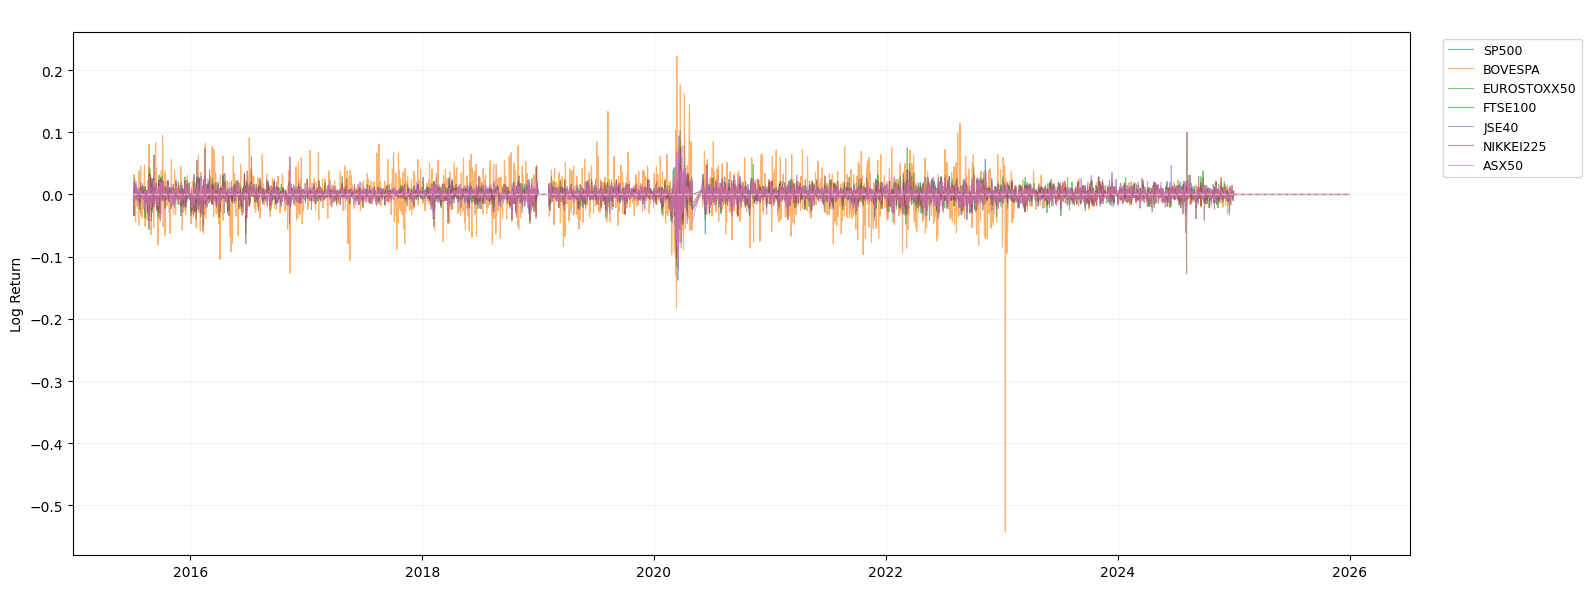

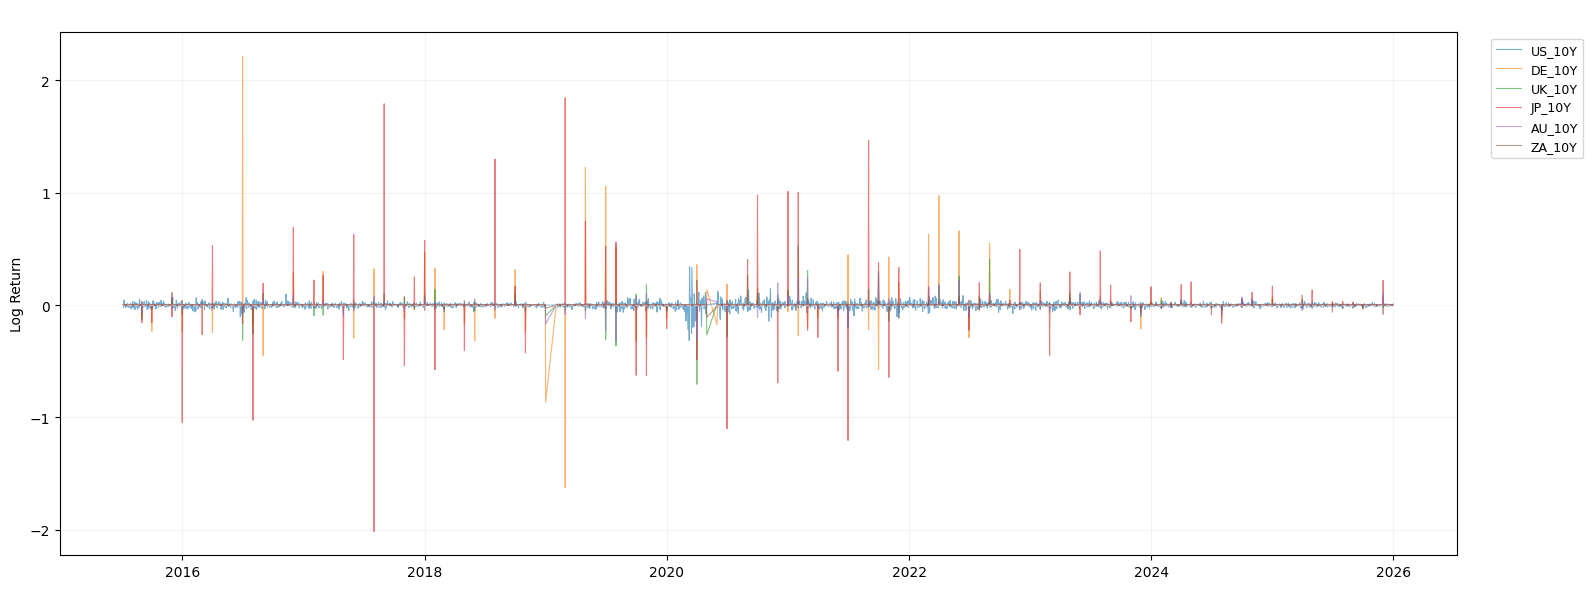

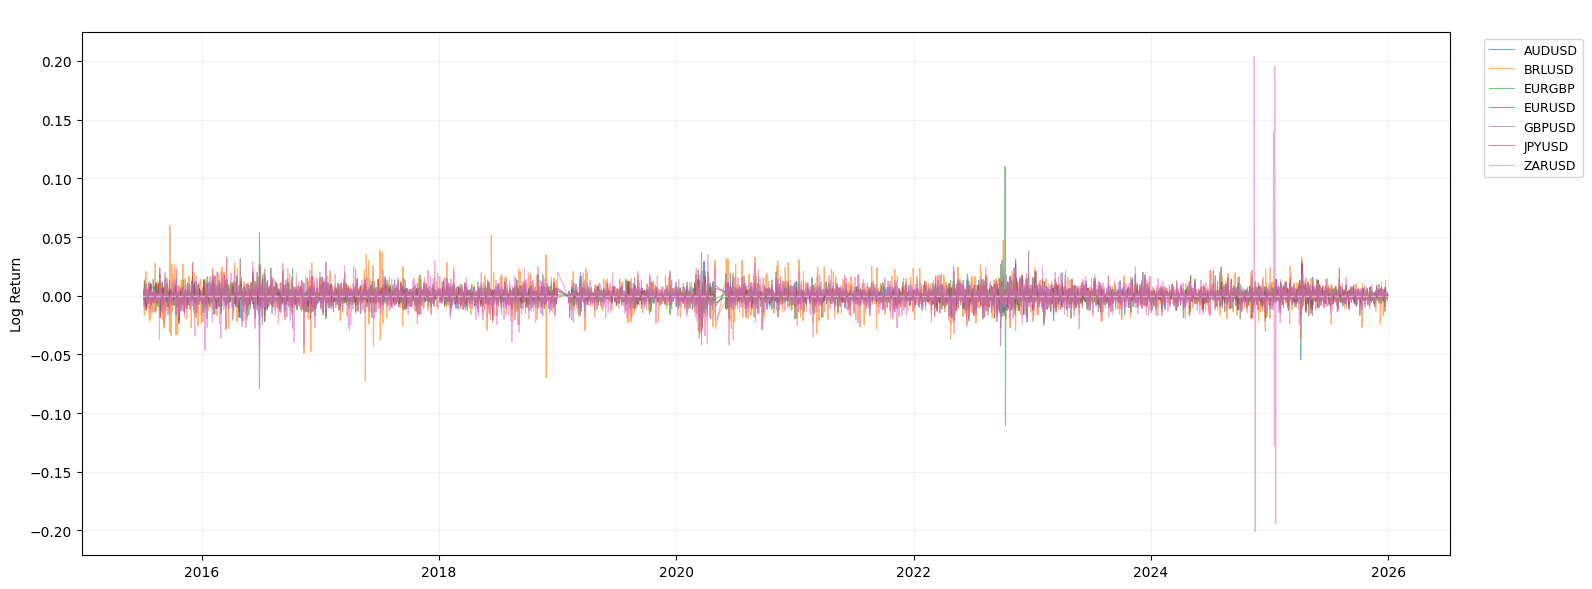

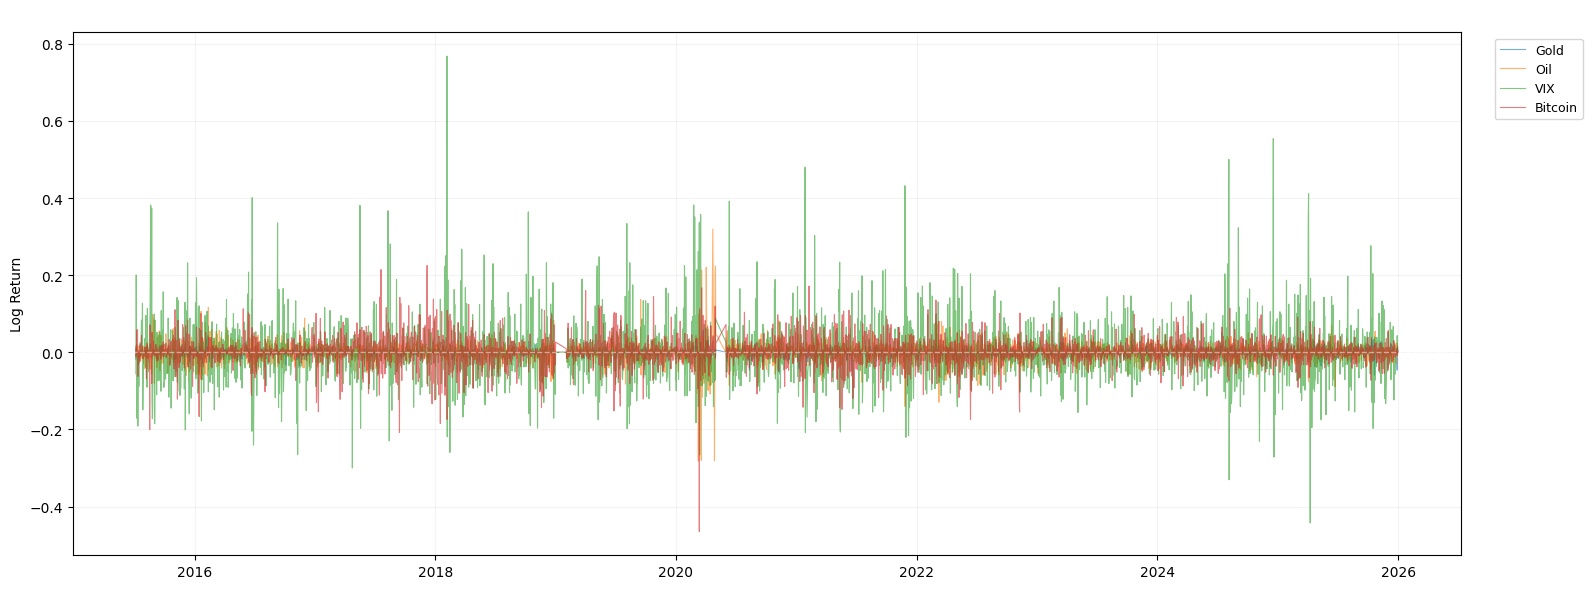

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate Log Returns for the entire universe
log_returns = np.log(all_assets / all_assets.shift(1)).dropna()

# Define sector groupings based on your study components
sector_groups = {
    "Equity Indices": ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
    "10Y Bond Yields": [c for c in all_assets.columns if '10Y' in c],
    "Currencies (FX)": [c for c in all_assets.columns if 'USD' in c or 'EURGBP' in c],
    "Risk Factors & Crypto": ['Gold', 'Oil', 'VIX', 'Bitcoin']
}

for sector_name, tickers in sector_groups.items():
    # Filter for tickers actually present in the dataframe
    valid_tickers = [t for t in tickers if t in log_returns.columns]

    if not valid_tickers:
        continue

    plt.figure(figsize=(16, 6))

    # Overlay each ticker's log-returns
    for ticker in valid_tickers:
        plt.plot(log_returns.index, log_returns[ticker], label=ticker, alpha=0.6, linewidth=0.8)

    plt.axhline(0, color='white', linestyle='--', linewidth=1, alpha=0.5)
    plt.title(f"Overlay: Daily Log-Returns — {sector_name}", fontsize=14, color='white')
    plt.ylabel("Log Return")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ─── Global Plot Style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0',
    'grid.color': '#2a2d3d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
    'text.color': '#e0e0e0',
})

# ─── Your Index Color Palette ─────────────────────────────────────────────────
INDEX_COLORS = {
    'SP500':     '#4fc3f7',
    'Ibovespa':  '#81c784',
    'EUROSTOXX': '#ffb74d',
    'FTSE100':   '#f06292',
    'JSE40':     '#ce93d8',
    'Nikkei225': '#ff8a65',
    'ASX50':     '#4dd0e1',
    'Yields':    '#ce93d8',
    'FX':        '#4dd0e1',
    'Risk':      '#ff8a65'
}

In [10]:
def run_stationarity_plots(df, name, color):
    # Calculate Mean Log-Returns for the asset class
    # Log returns are preferred for stationarity in financial time series
    returns = np.log(df / df.shift(1)).dropna().mean(axis=1)

    # Augmented Dickey-Fuller Test
    # Null Hypothesis: The series has a unit root (is non-stationary)
    adf_res = adfuller(returns)
    p_val = adf_res[1]
    status = "Stationary" if p_val < 0.05 else "Non-Stationary"

    # Create 3-panel visual: Returns, ACF, and PACF
    fig = plt.figure(figsize=(18, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1])

    # 1. Log-Return Plot
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(returns, color=color, linewidth=0.8, alpha=0.9)
    ax0.set_title(f'{name} | Returns ({status})', color=color, loc='left')
    ax0.set_ylabel('Log Return')
    ax0.grid(True, alpha=0.3)
    # Add p-value box
    ax0.text(0.02, 0.95, f'ADF p-val: {p_val:.4f}', transform=ax0.transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(facecolor='#0f1117', edgecolor=color, alpha=0.7))

    # 2. ACF Plot (Autocorrelation)
    # Shows how a value correlates with its own lagged versions
    ax1 = fig.add_subplot(gs[1])
    plot_acf(returns, ax=ax1, lags=30, color=color, vlines_kw={'colors': color}, alpha=0.1)
    ax1.set_title('ACF (Persistence)', fontsize=10)
    ax1.set_ylim(-0.2, 0.2) # Focused scale for returns

    # 3. PACF Plot (Partial Autocorrelation)
    # Identifies the direct correlation of a lag by removing intermediate effects
    ax2 = fig.add_subplot(gs[2])
    plot_pacf(returns, ax=ax2, lags=30, color=color, vlines_kw={'colors': color}, alpha=0.1)
    ax2.set_title('PACF (Direct Impact)', fontsize=10)
    ax2.set_ylim(-0.2, 0.2)

    plt.tight_layout()
    plt.show()

    return {'Asset': name, 'p-val': p_val, 'Result': status}

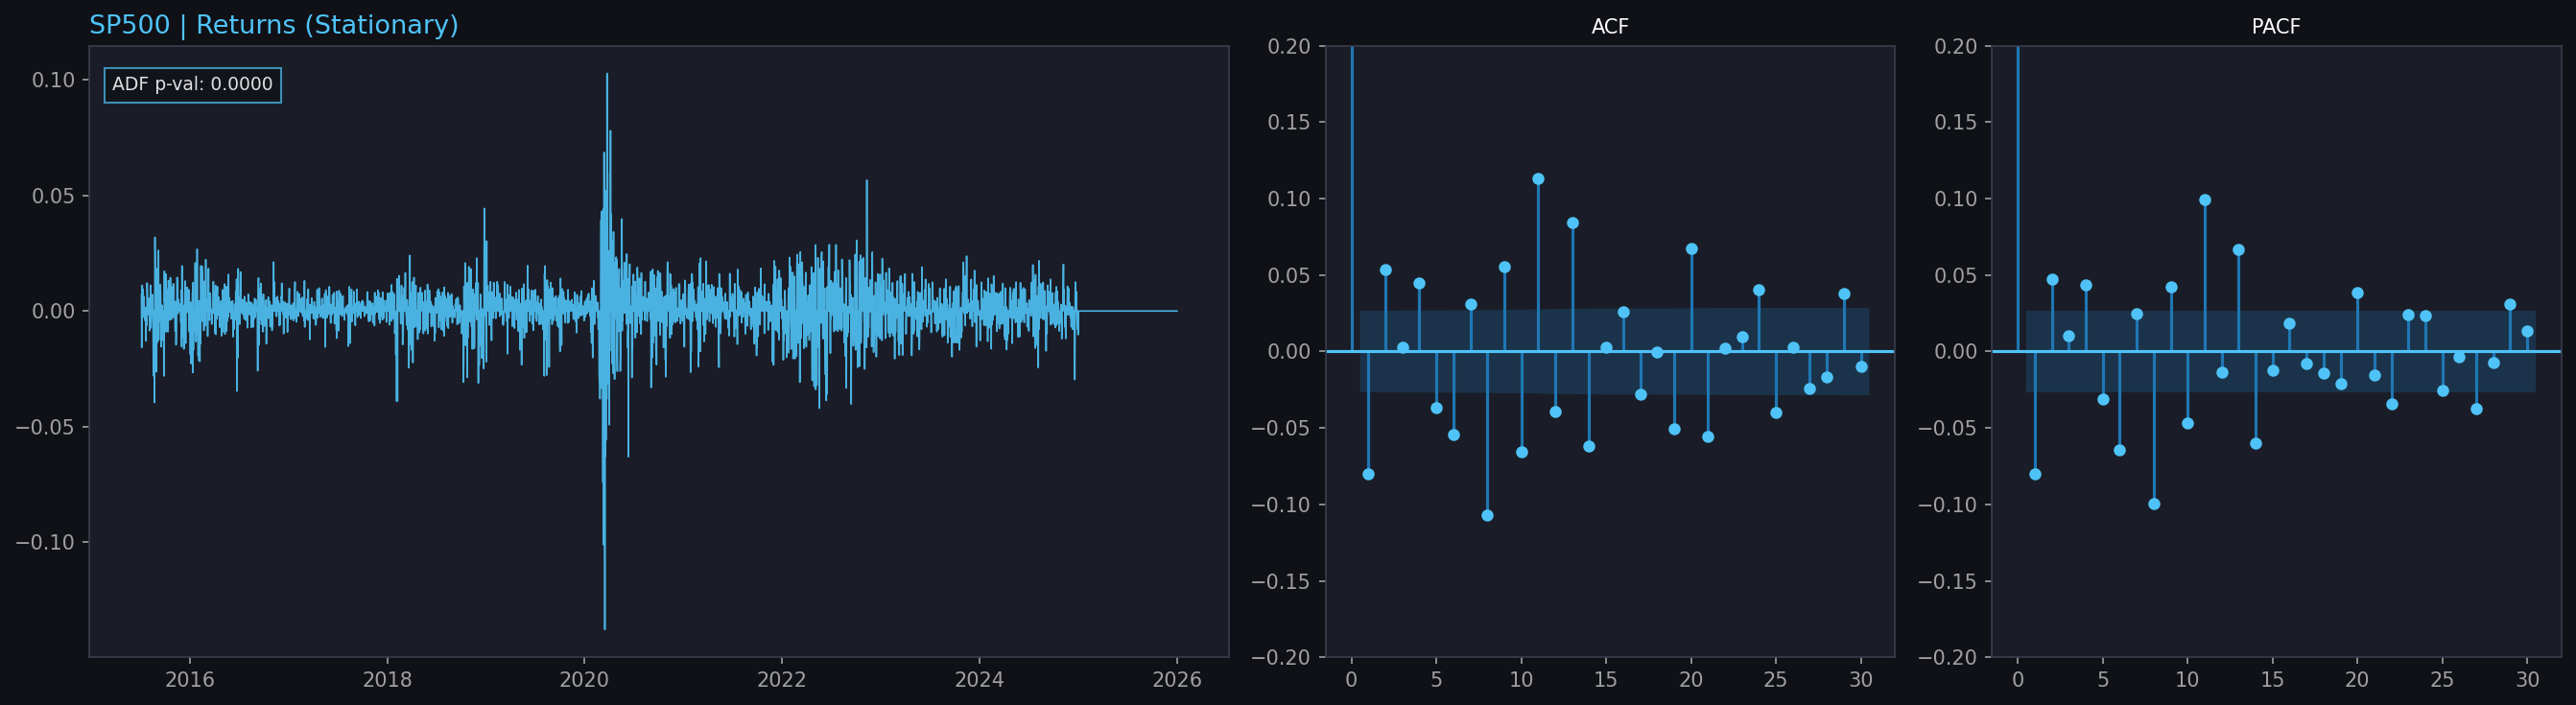

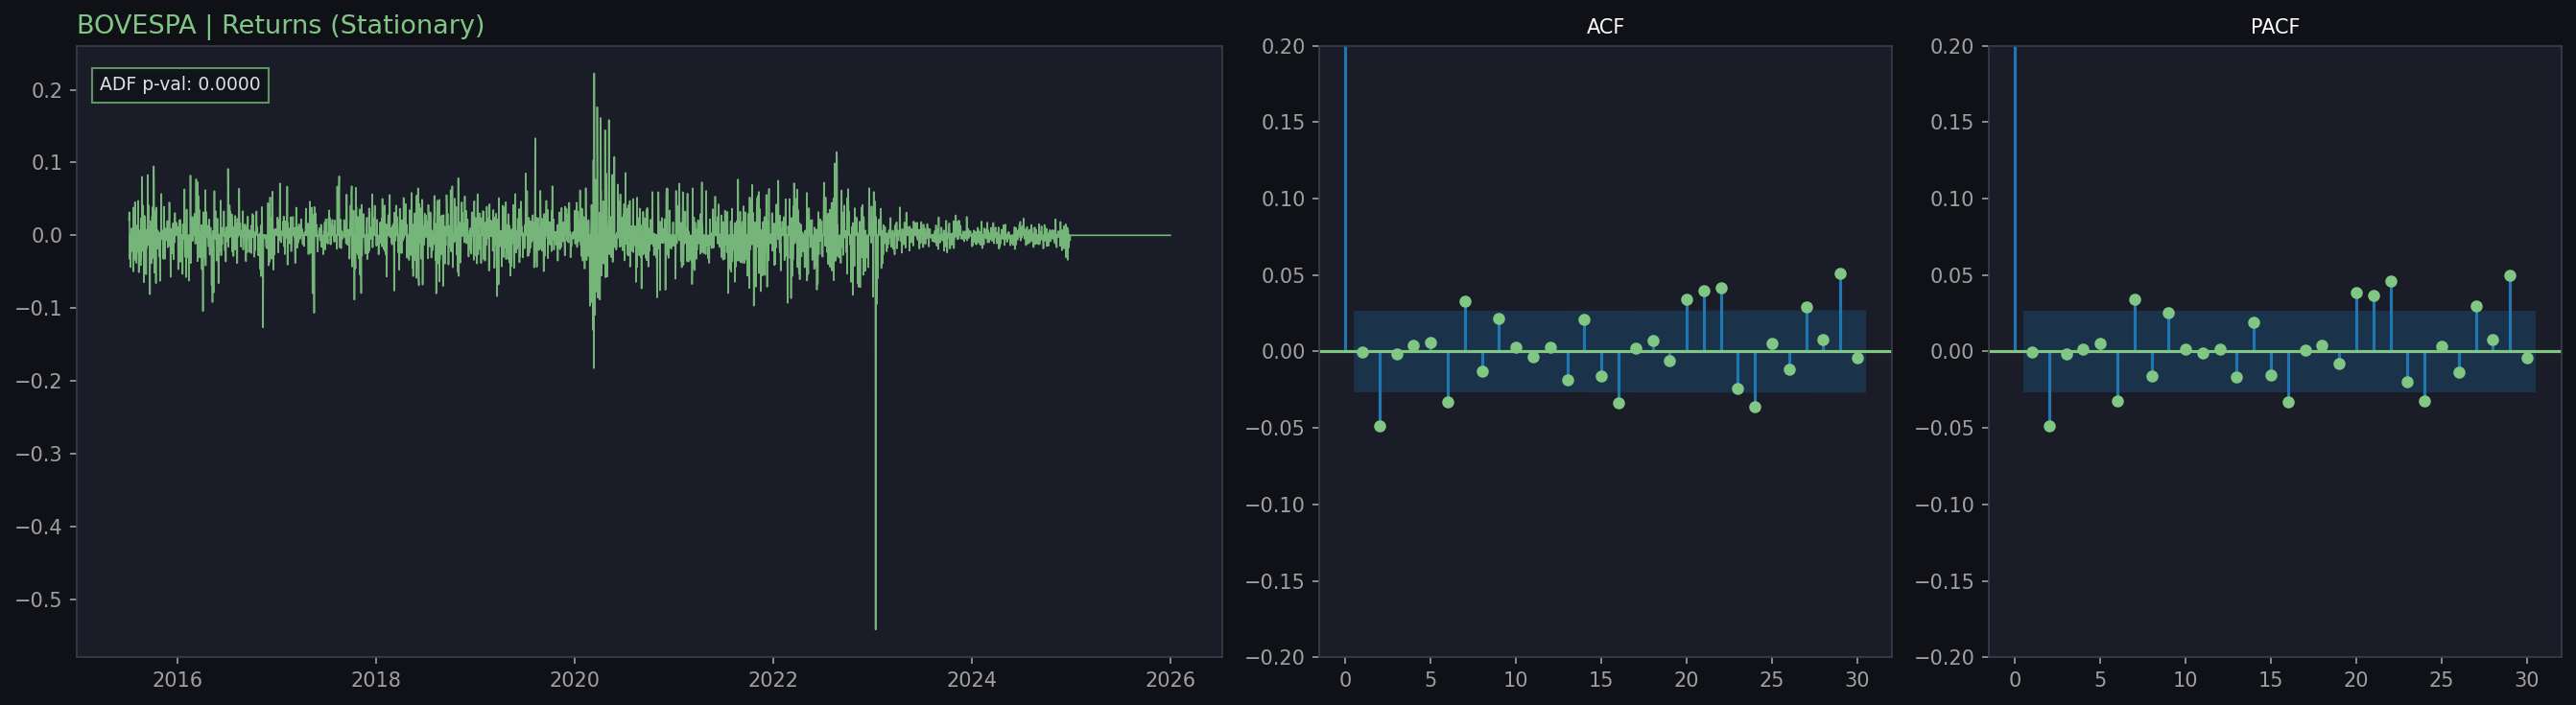

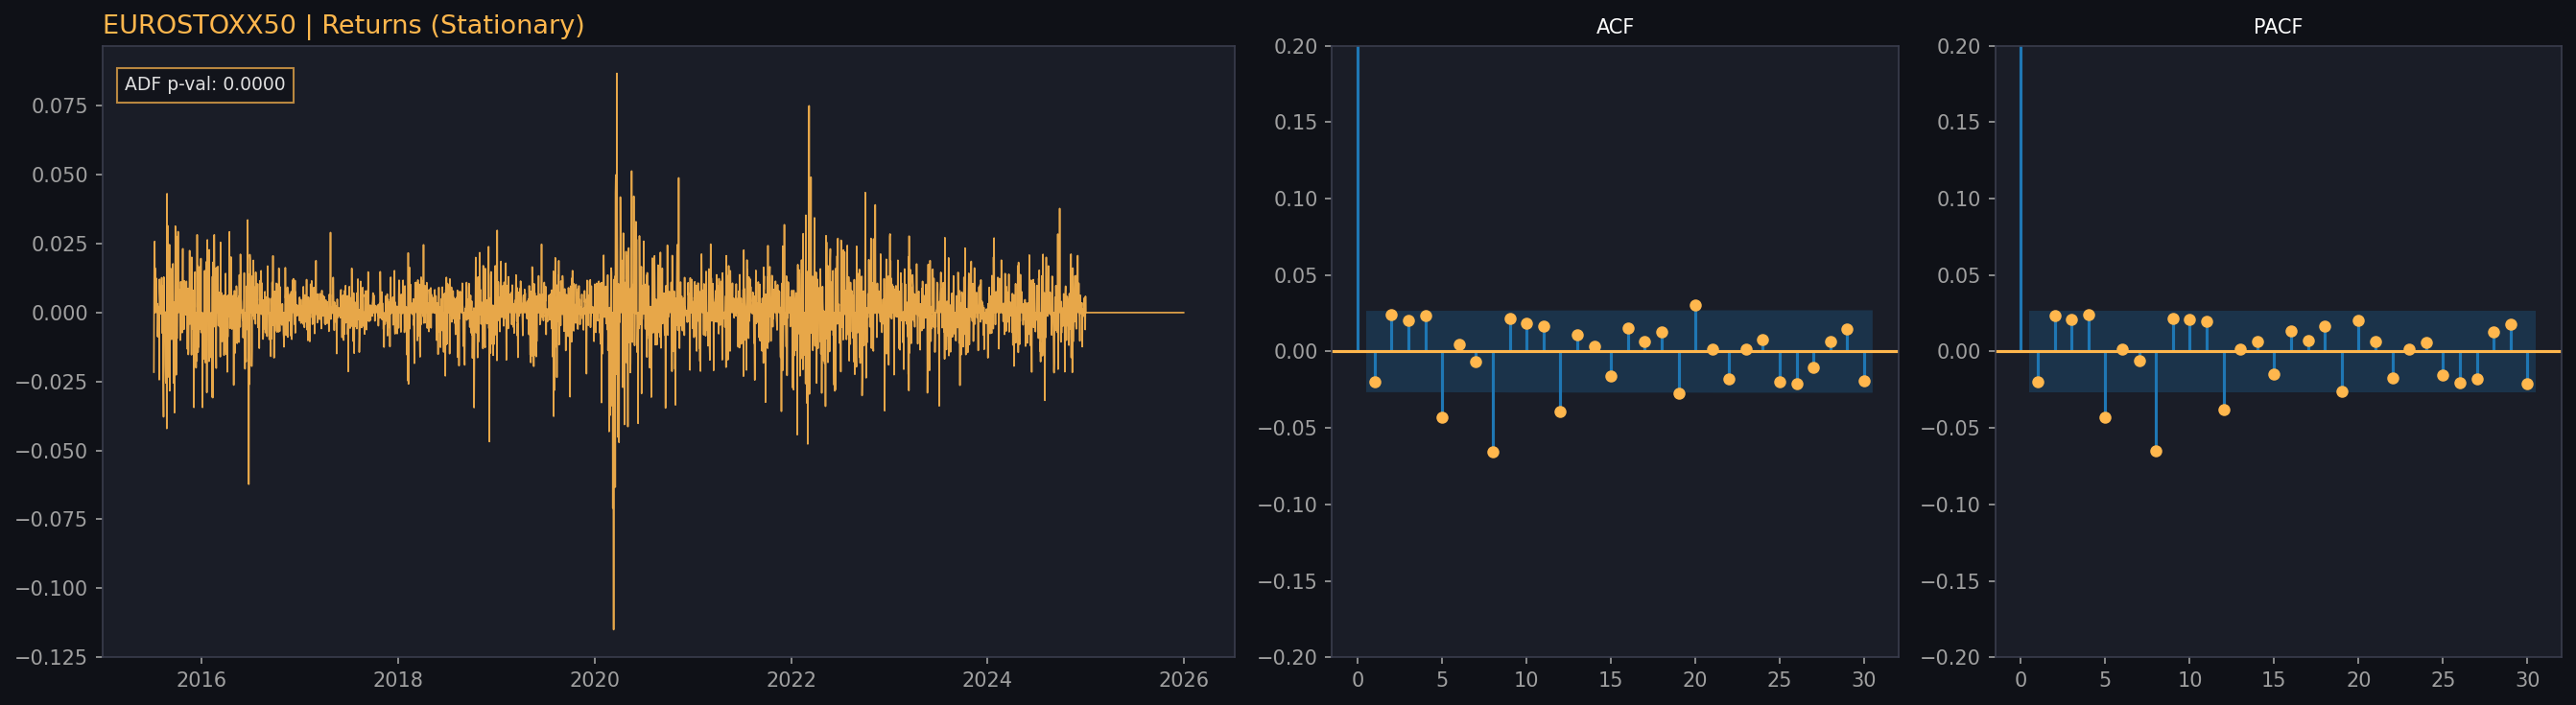

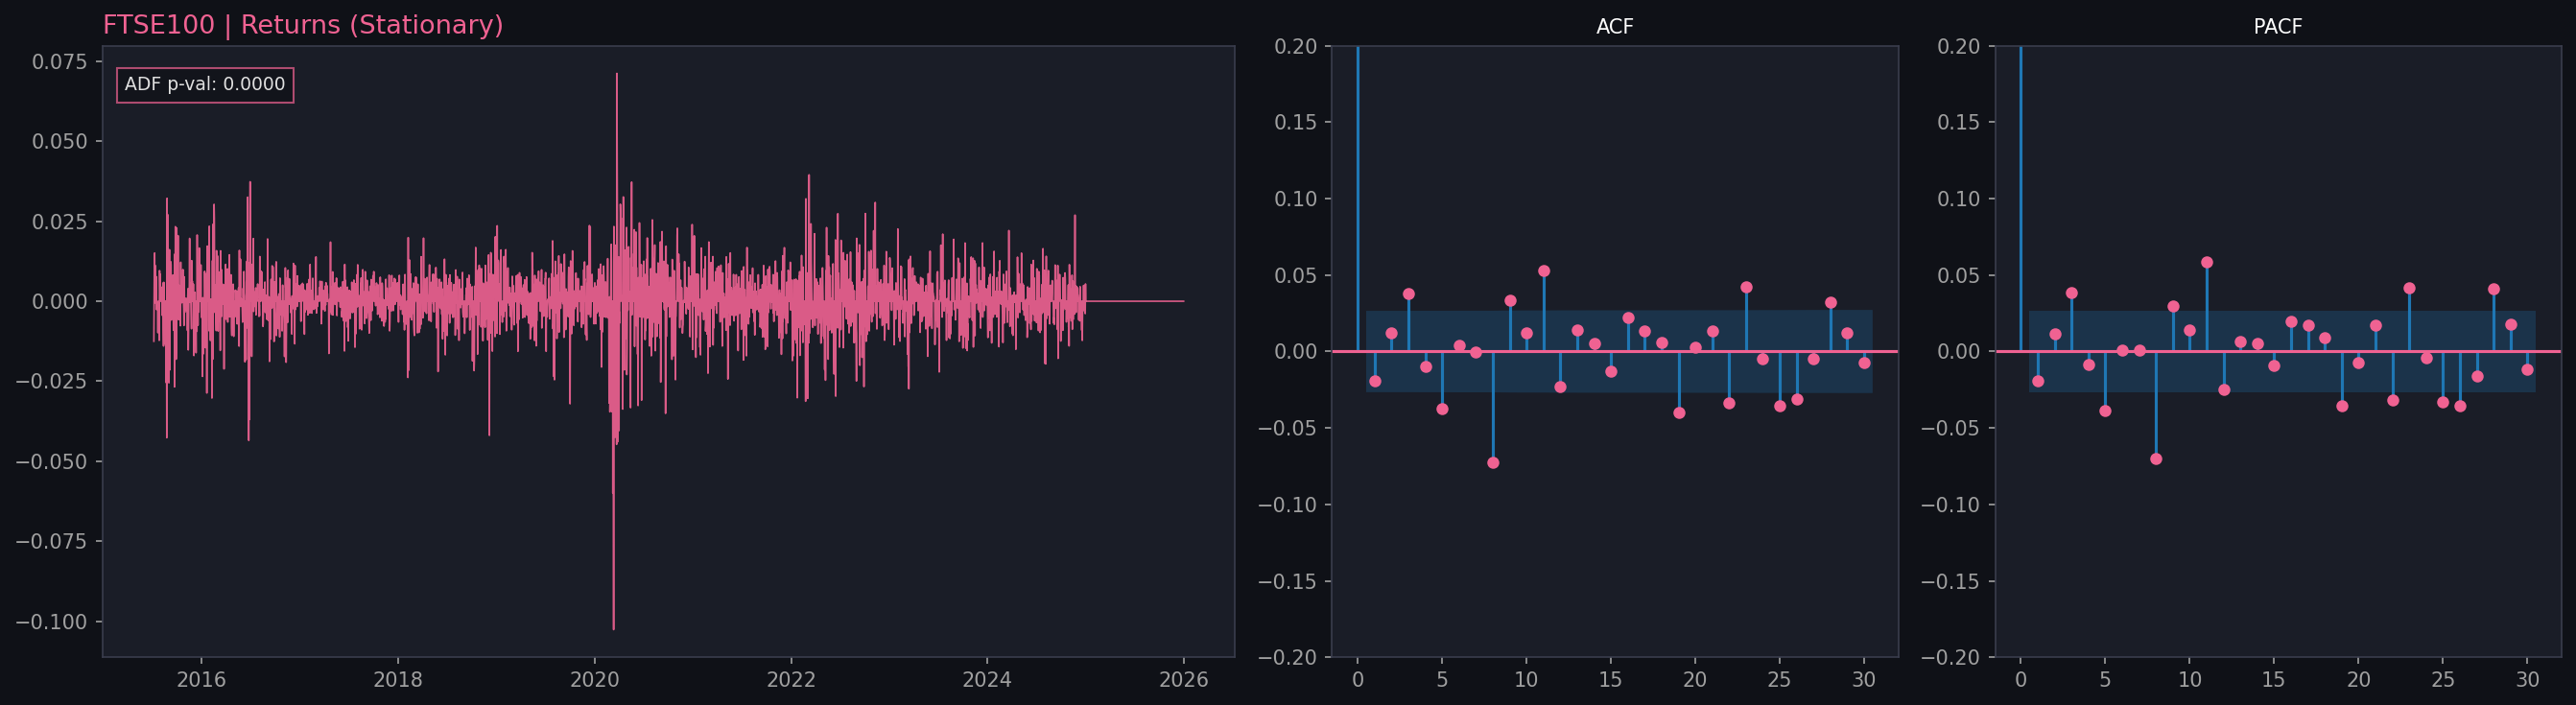

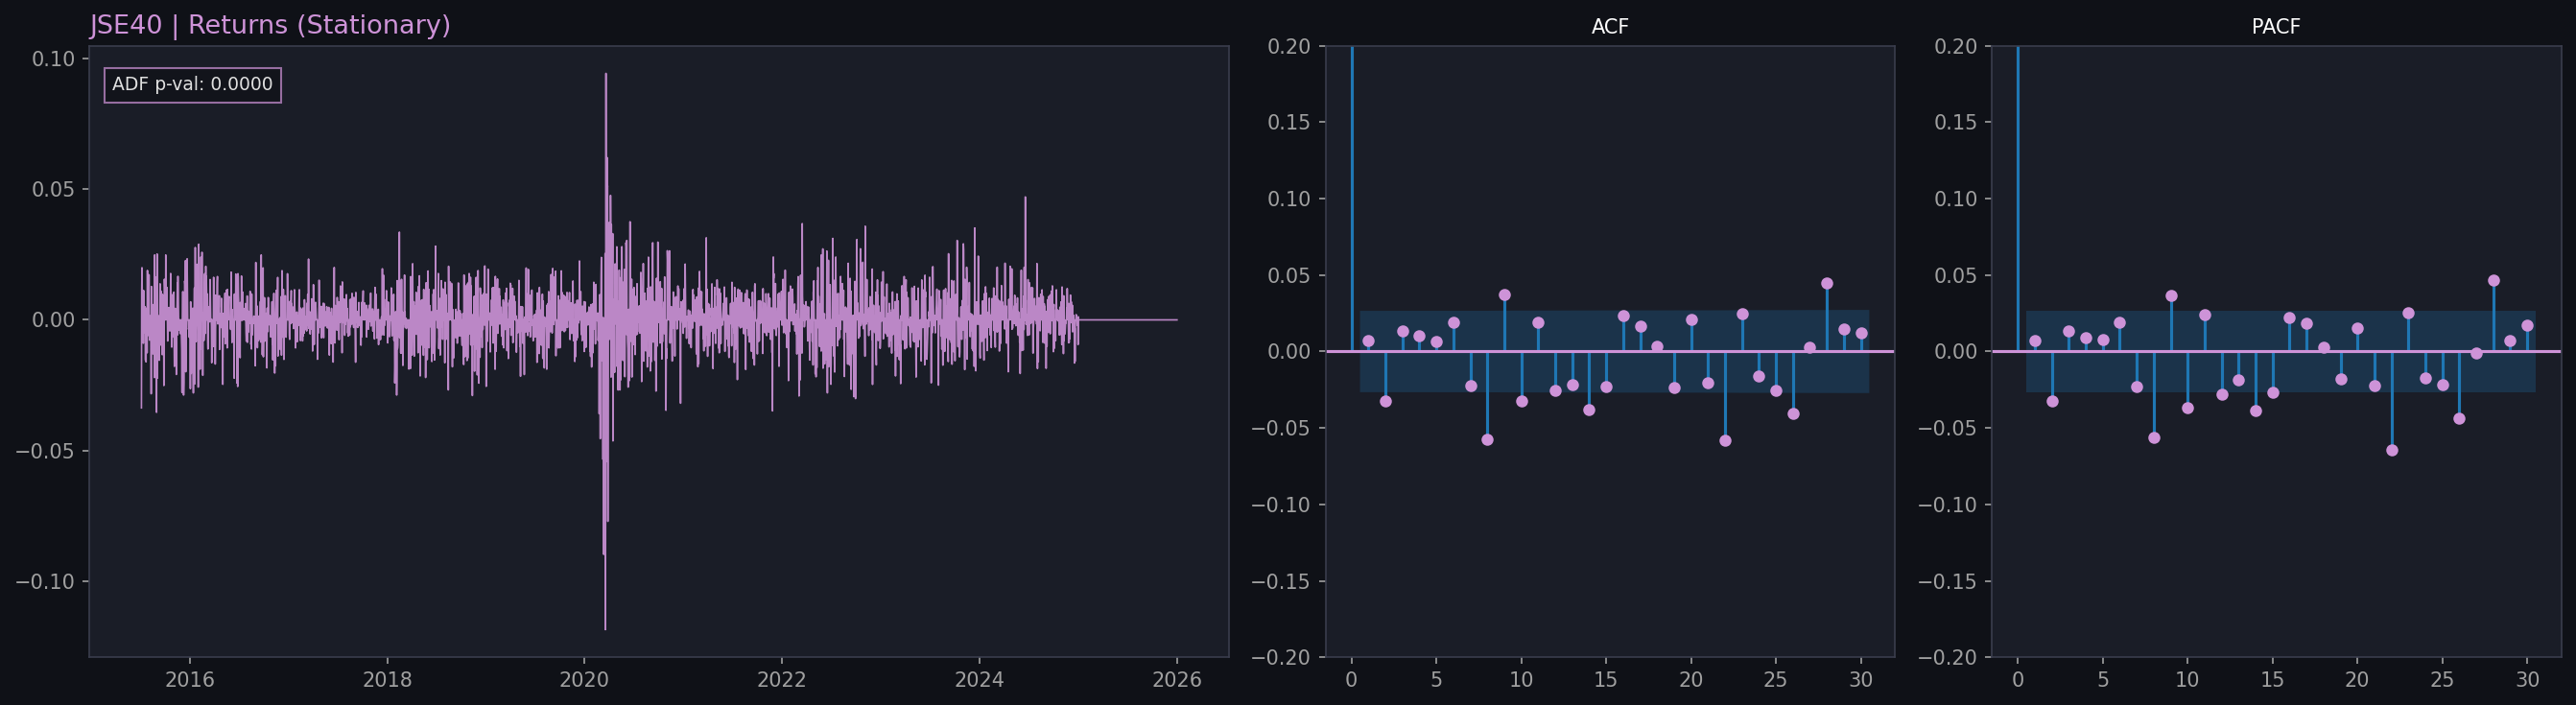

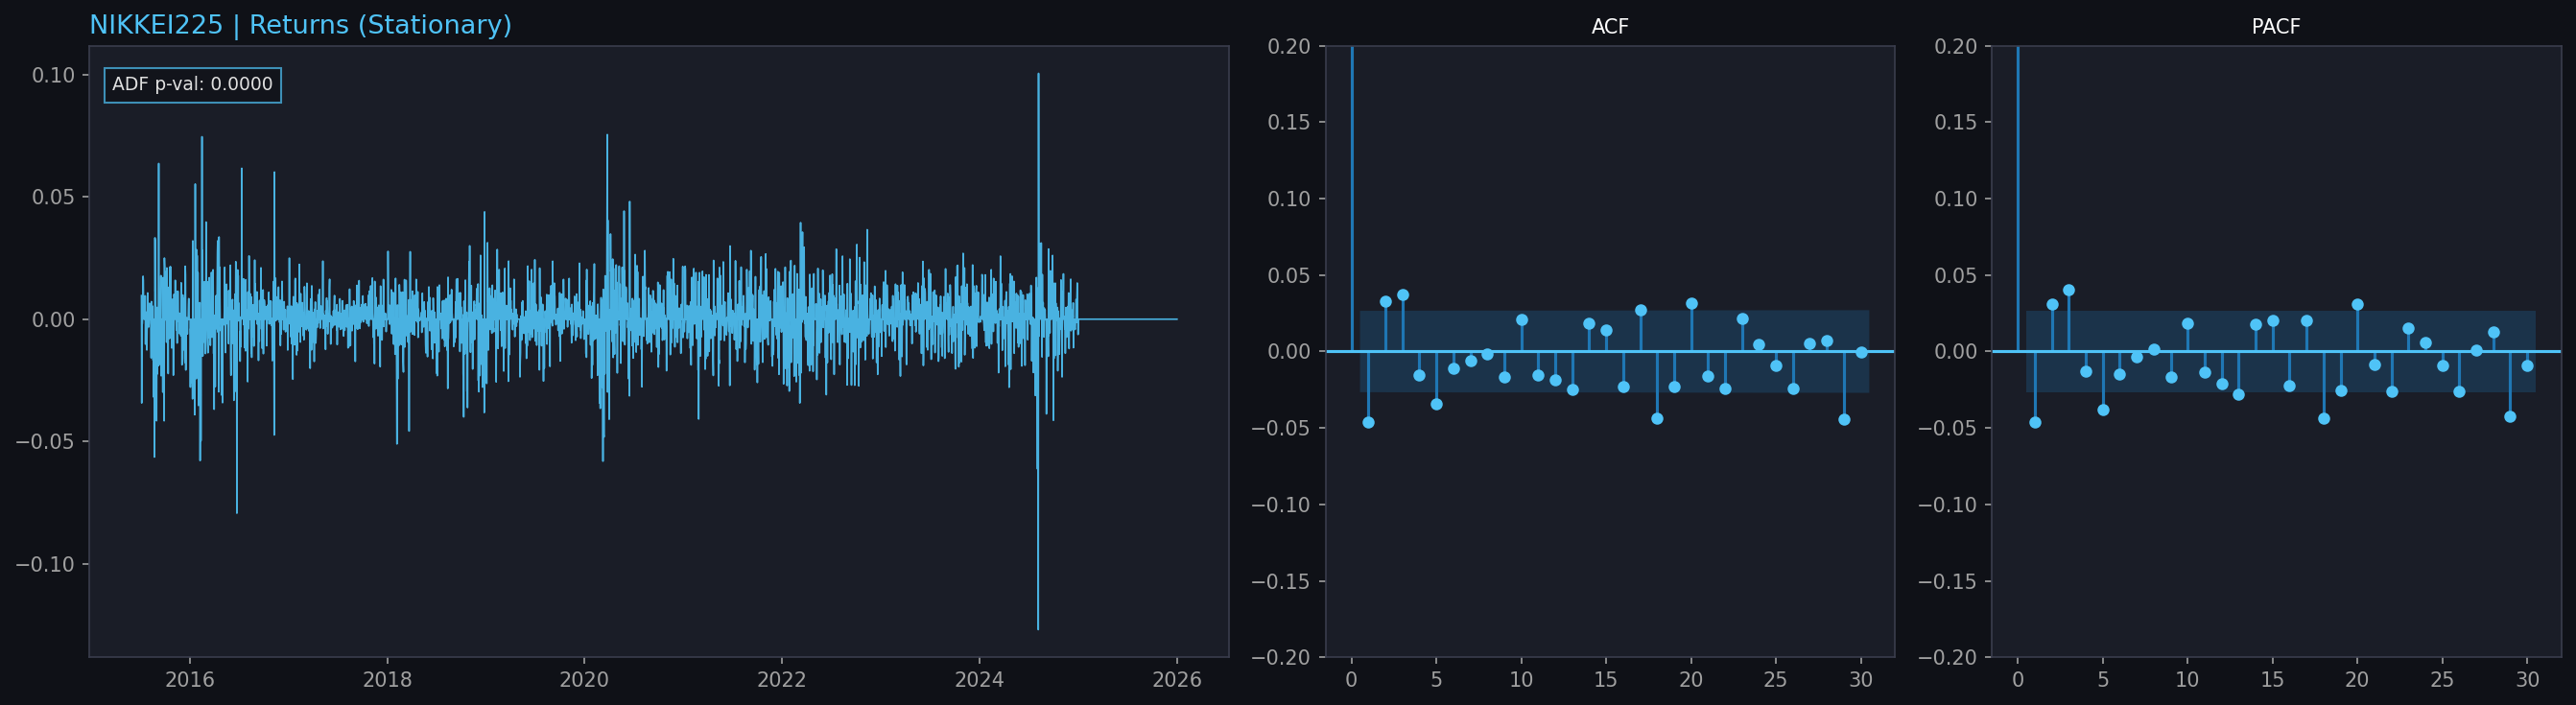

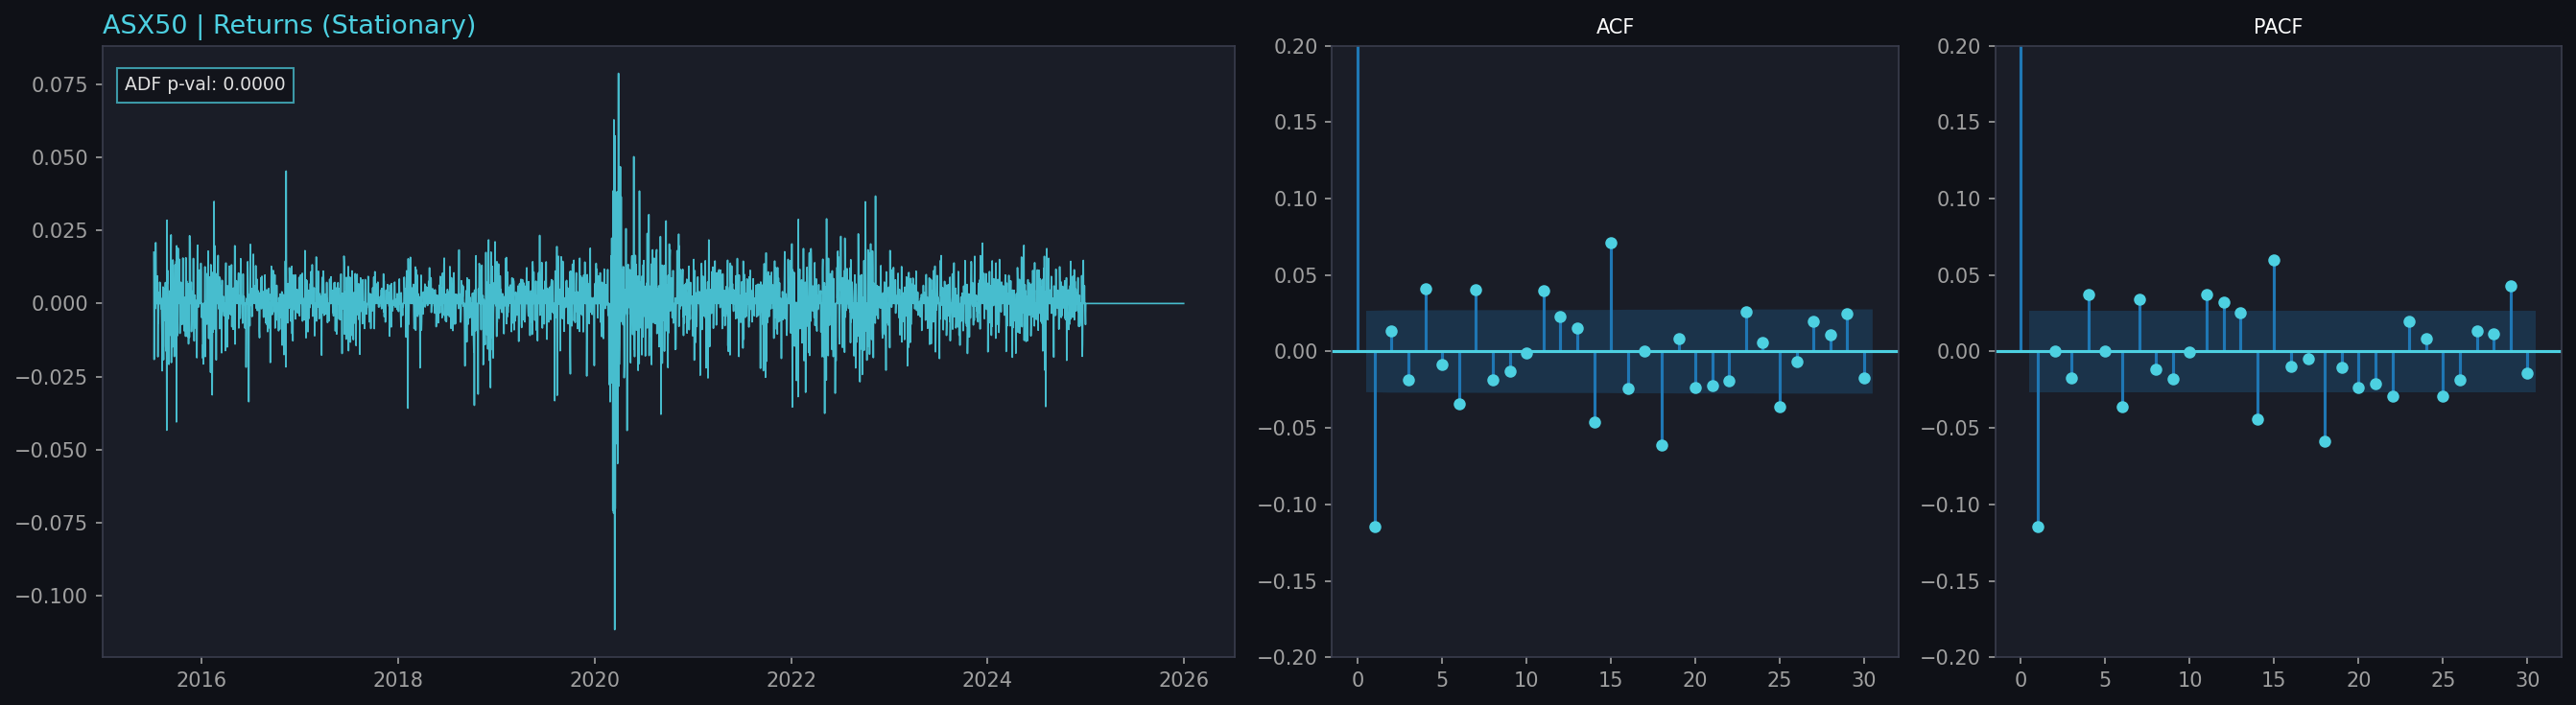

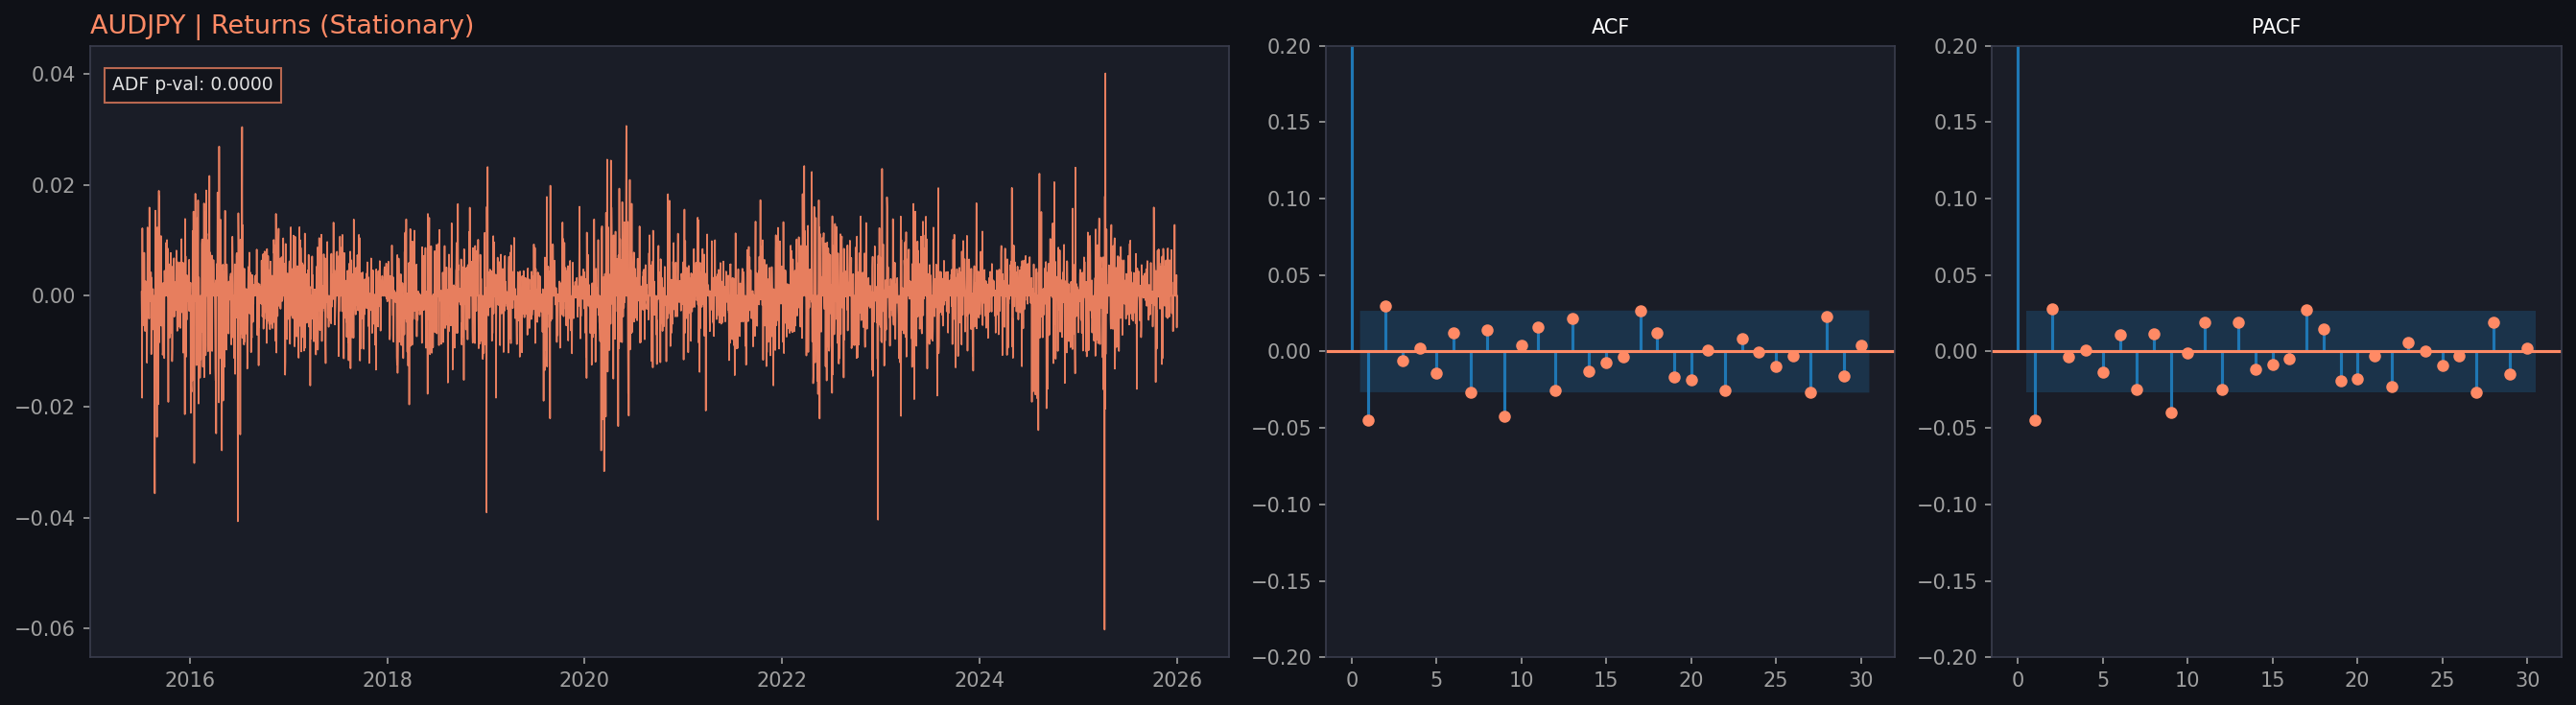

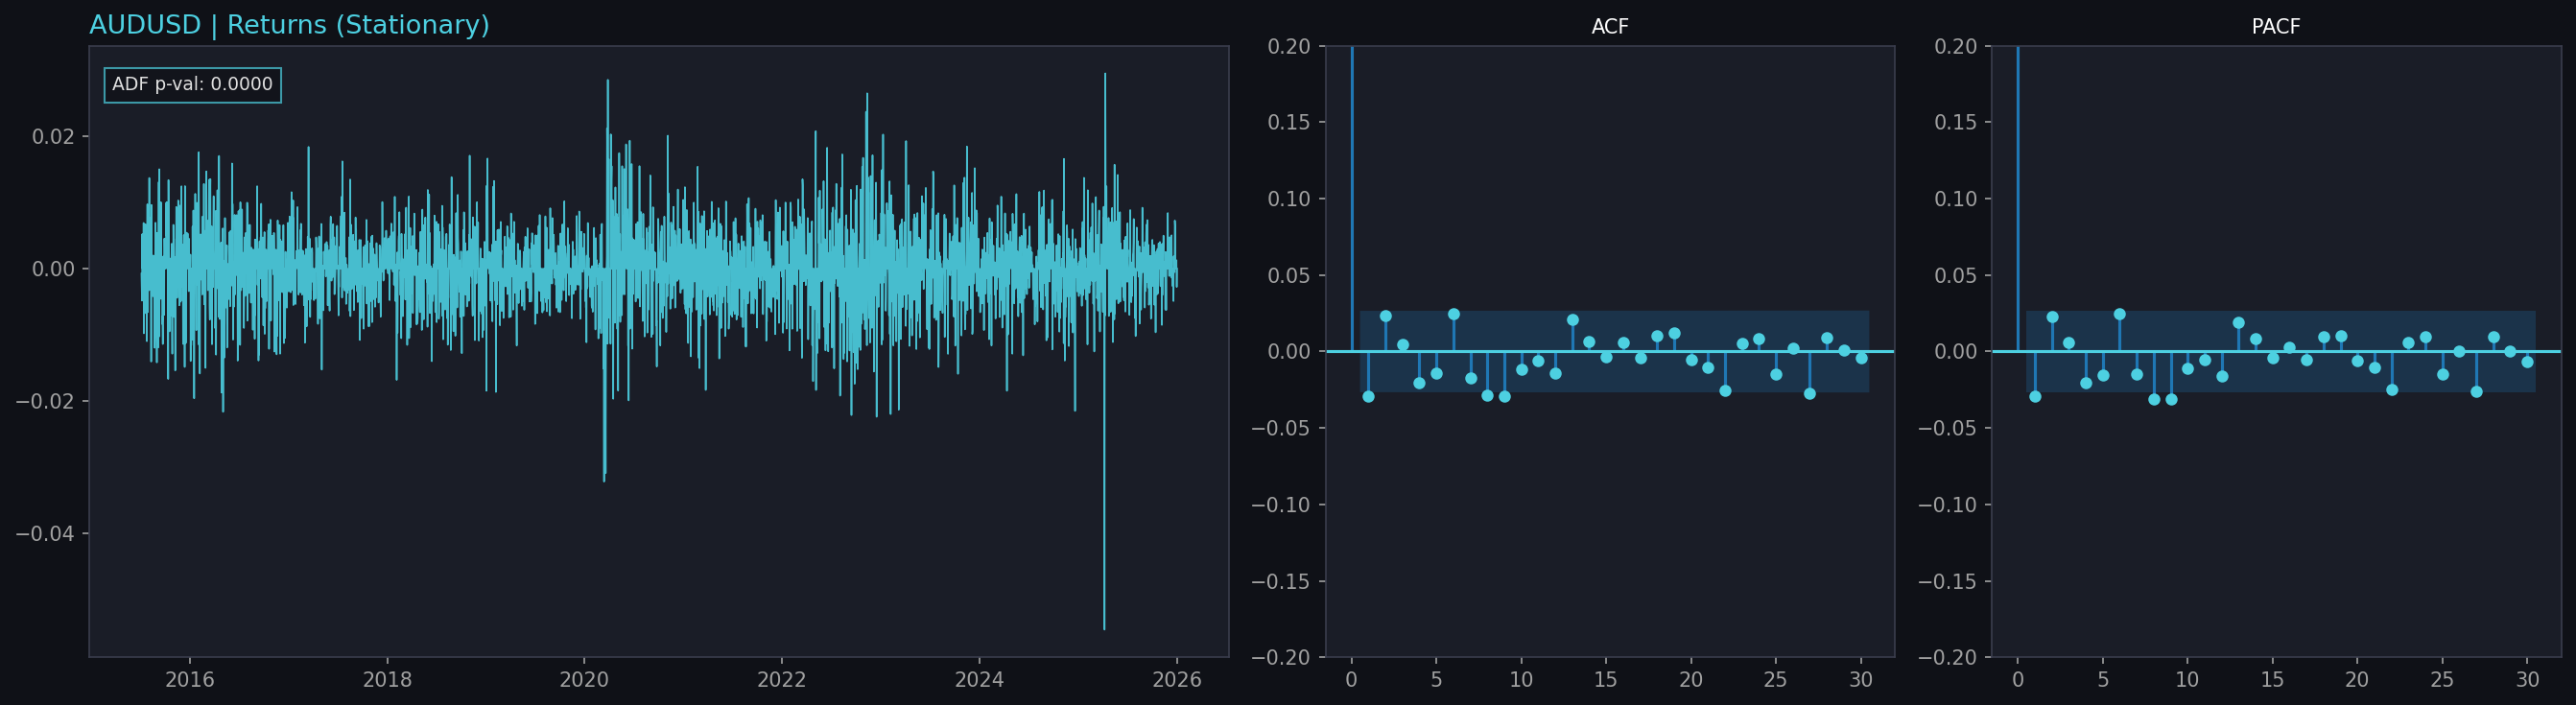

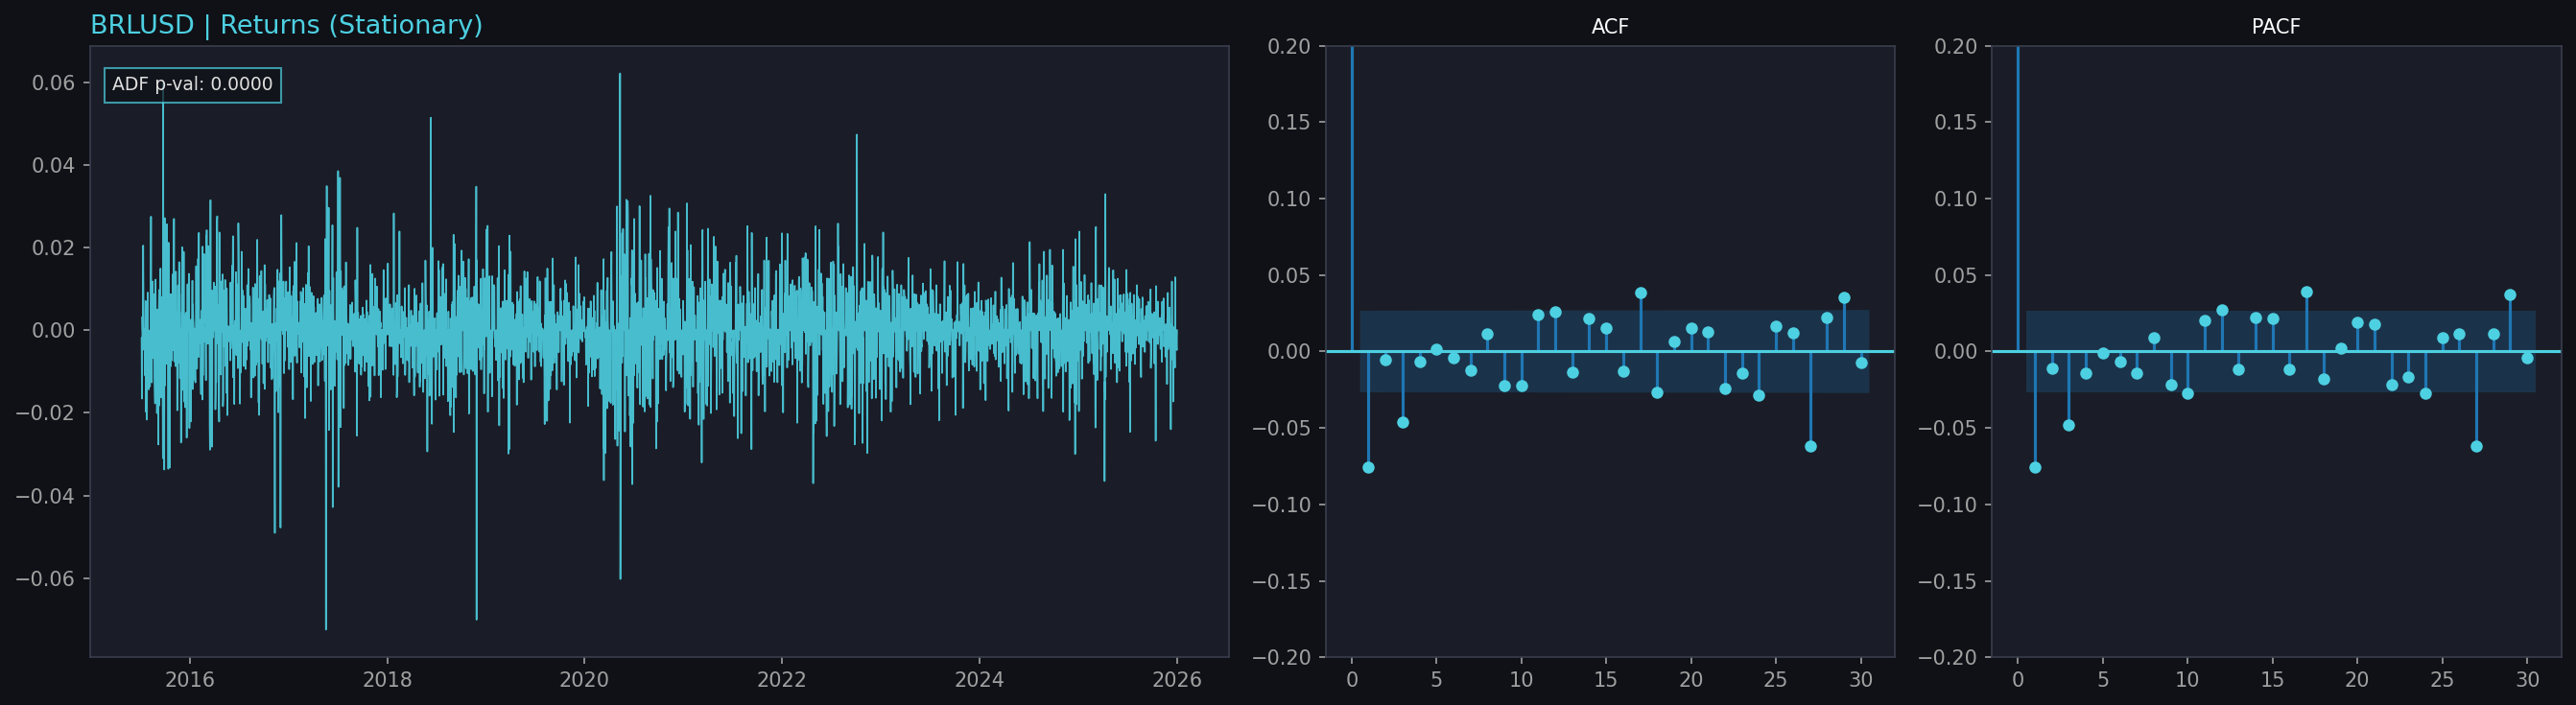

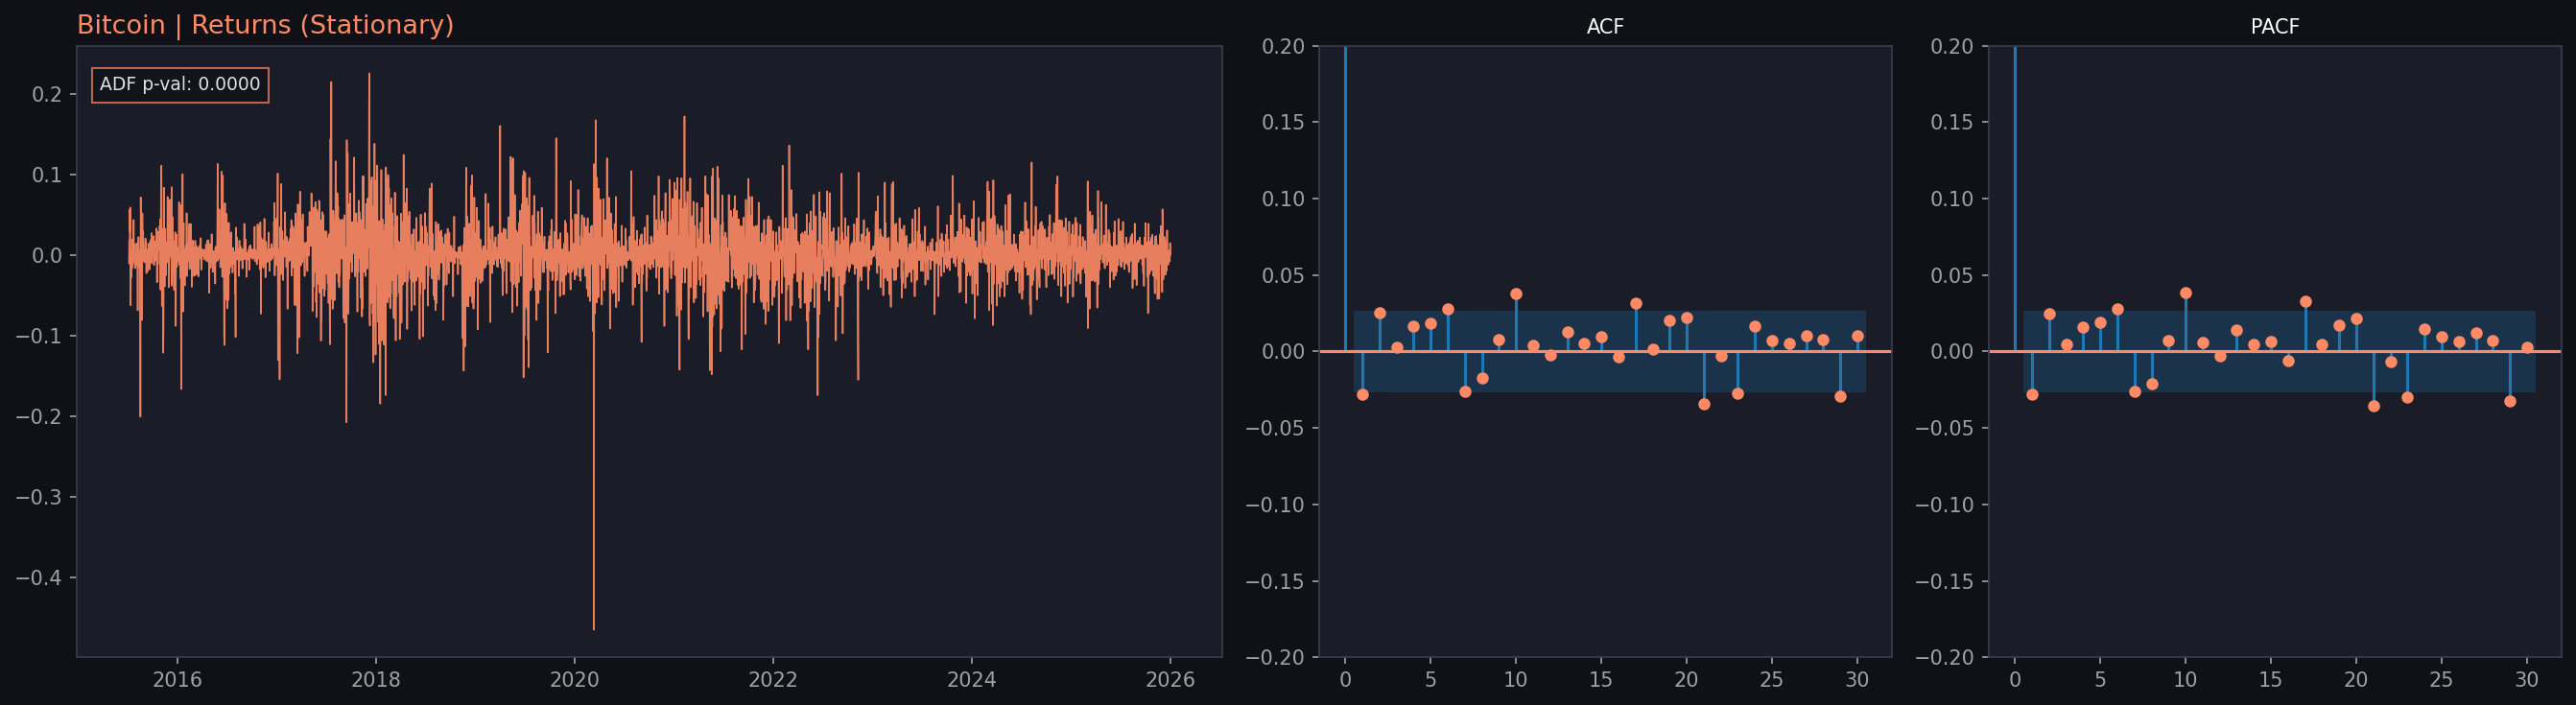

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


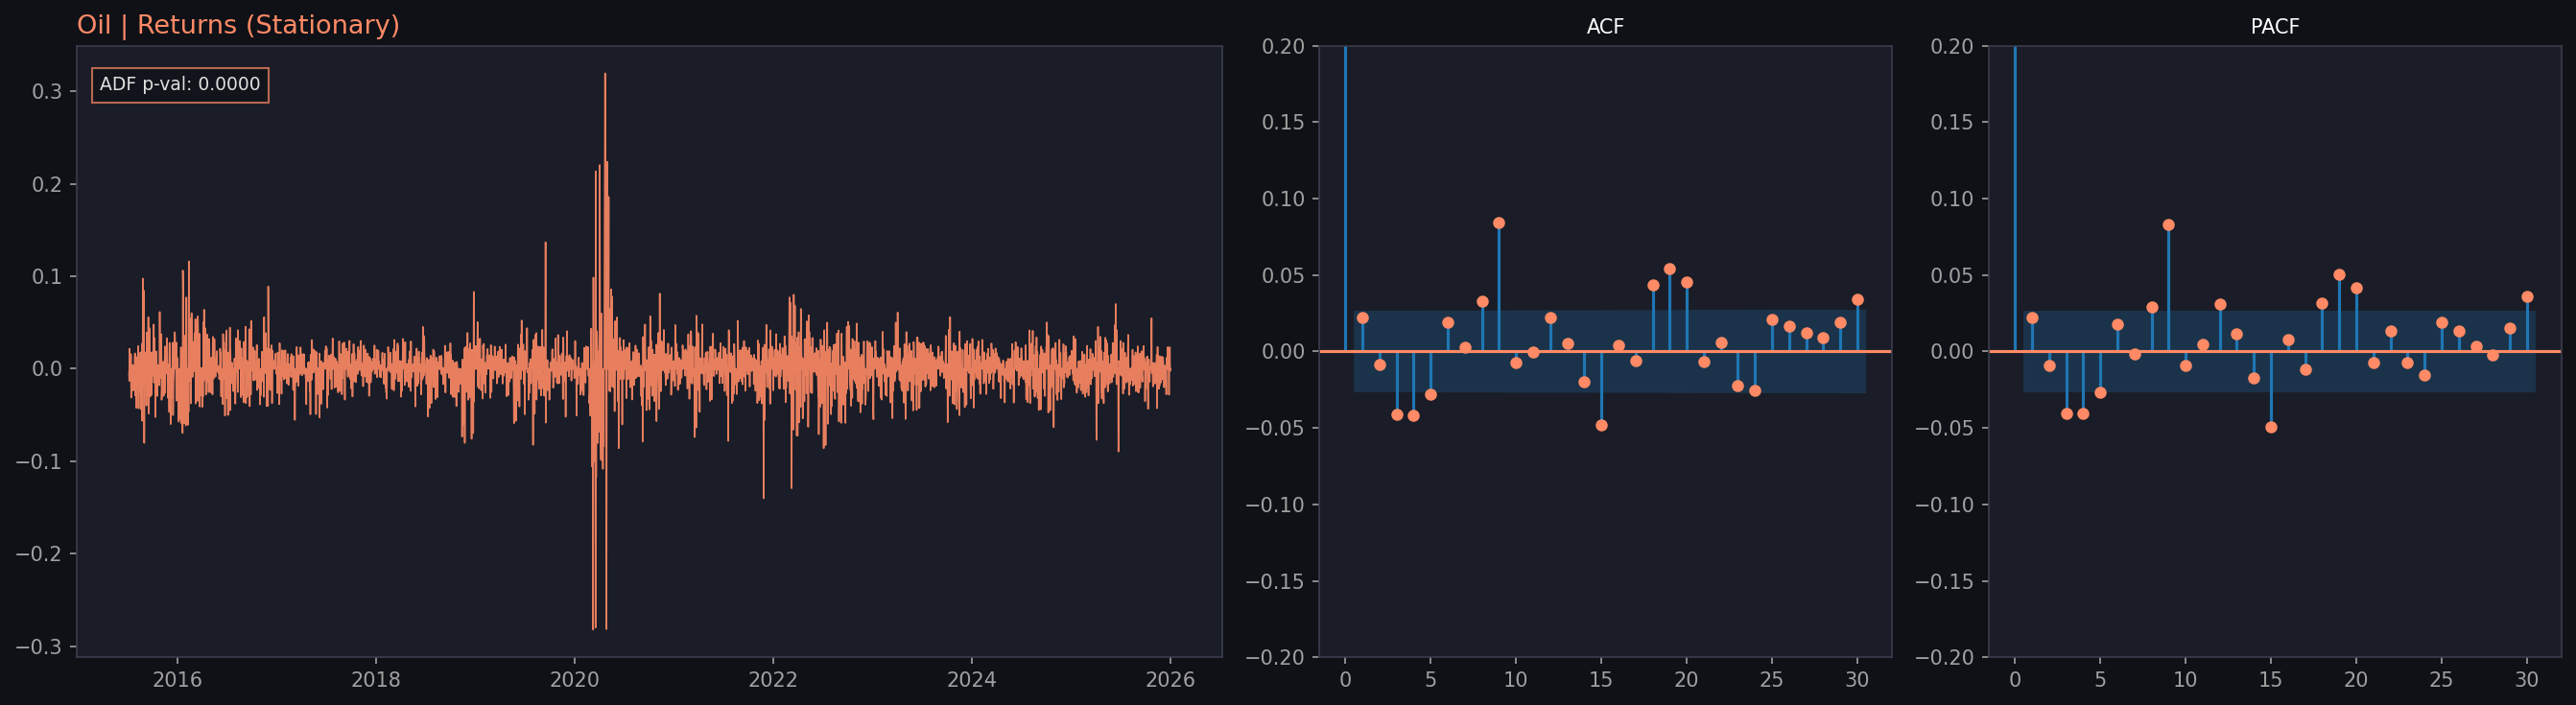

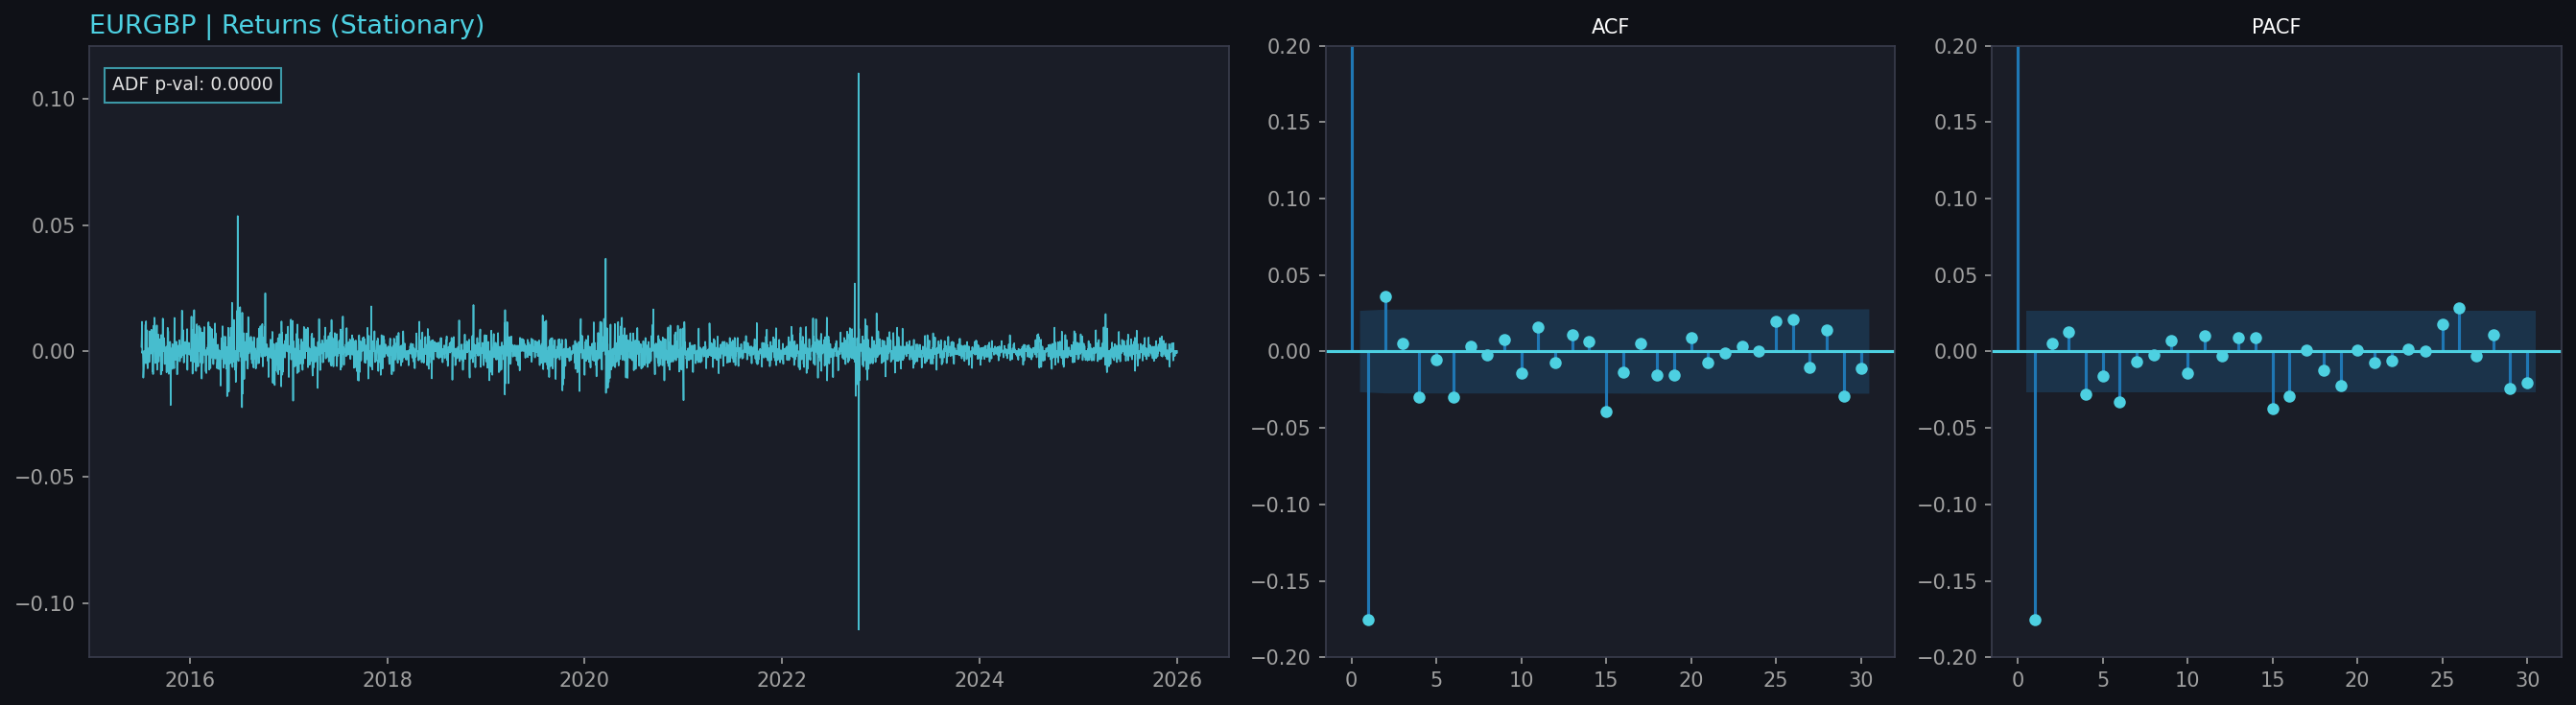

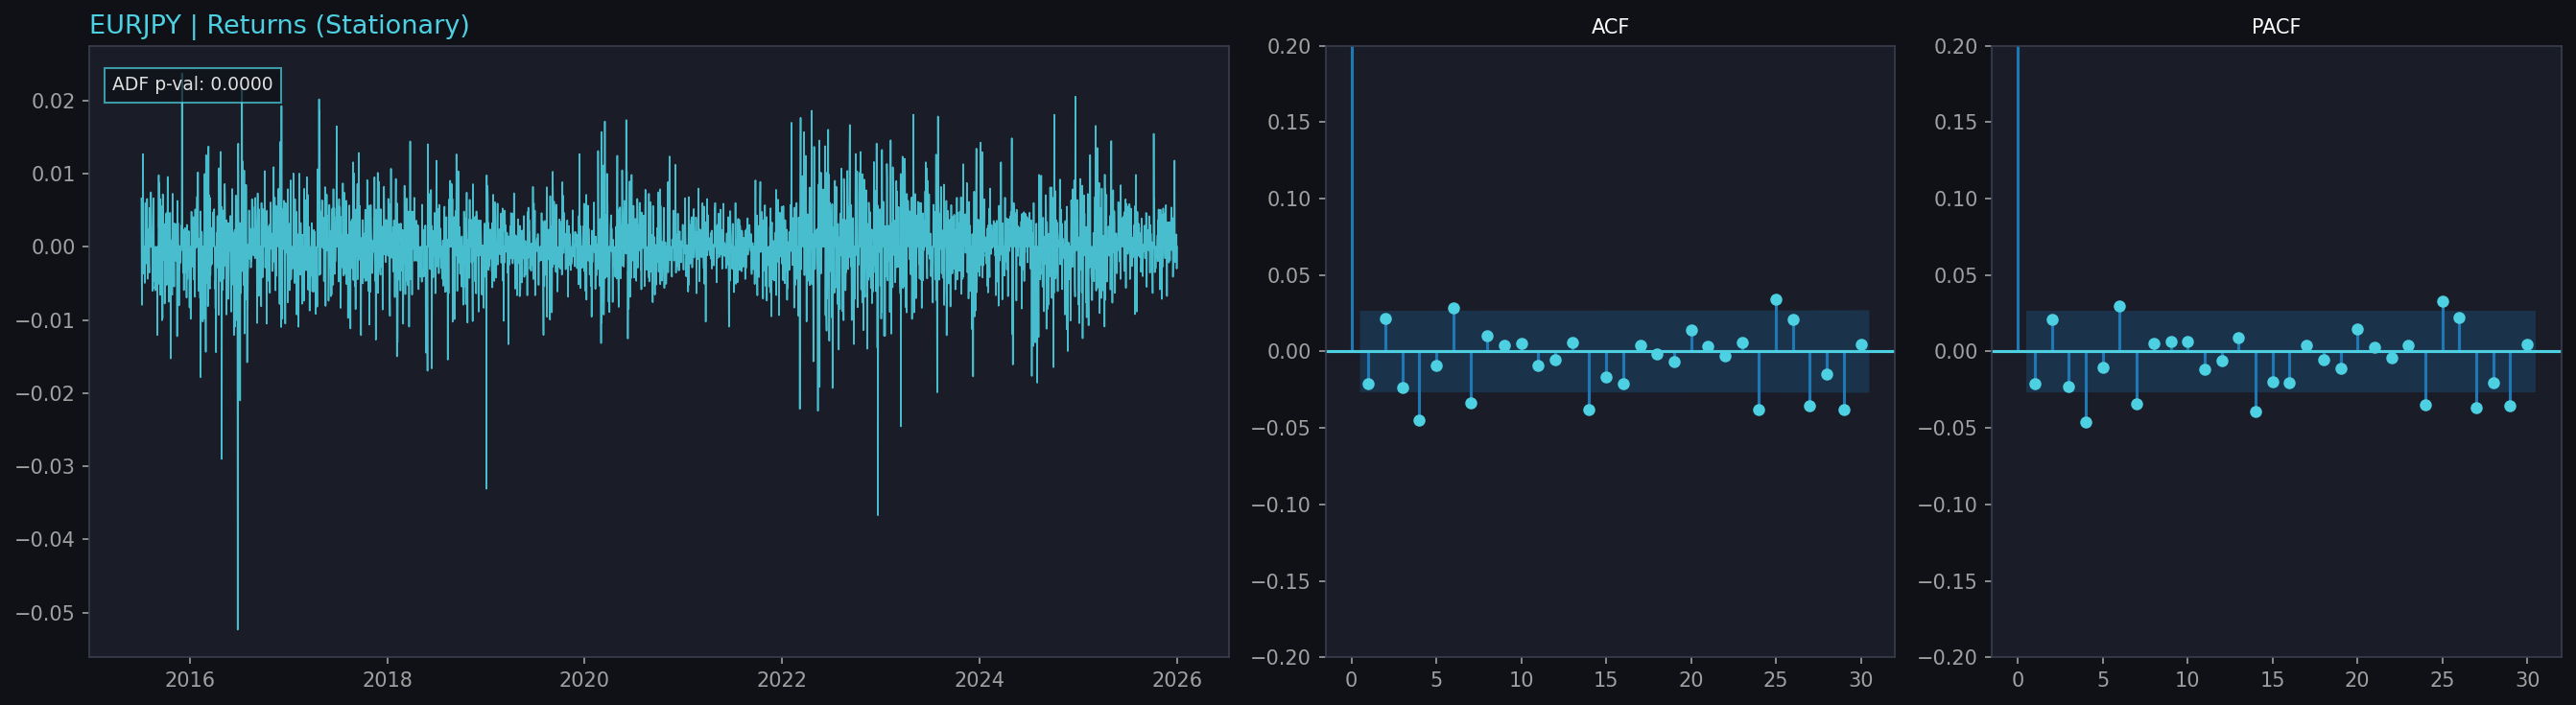

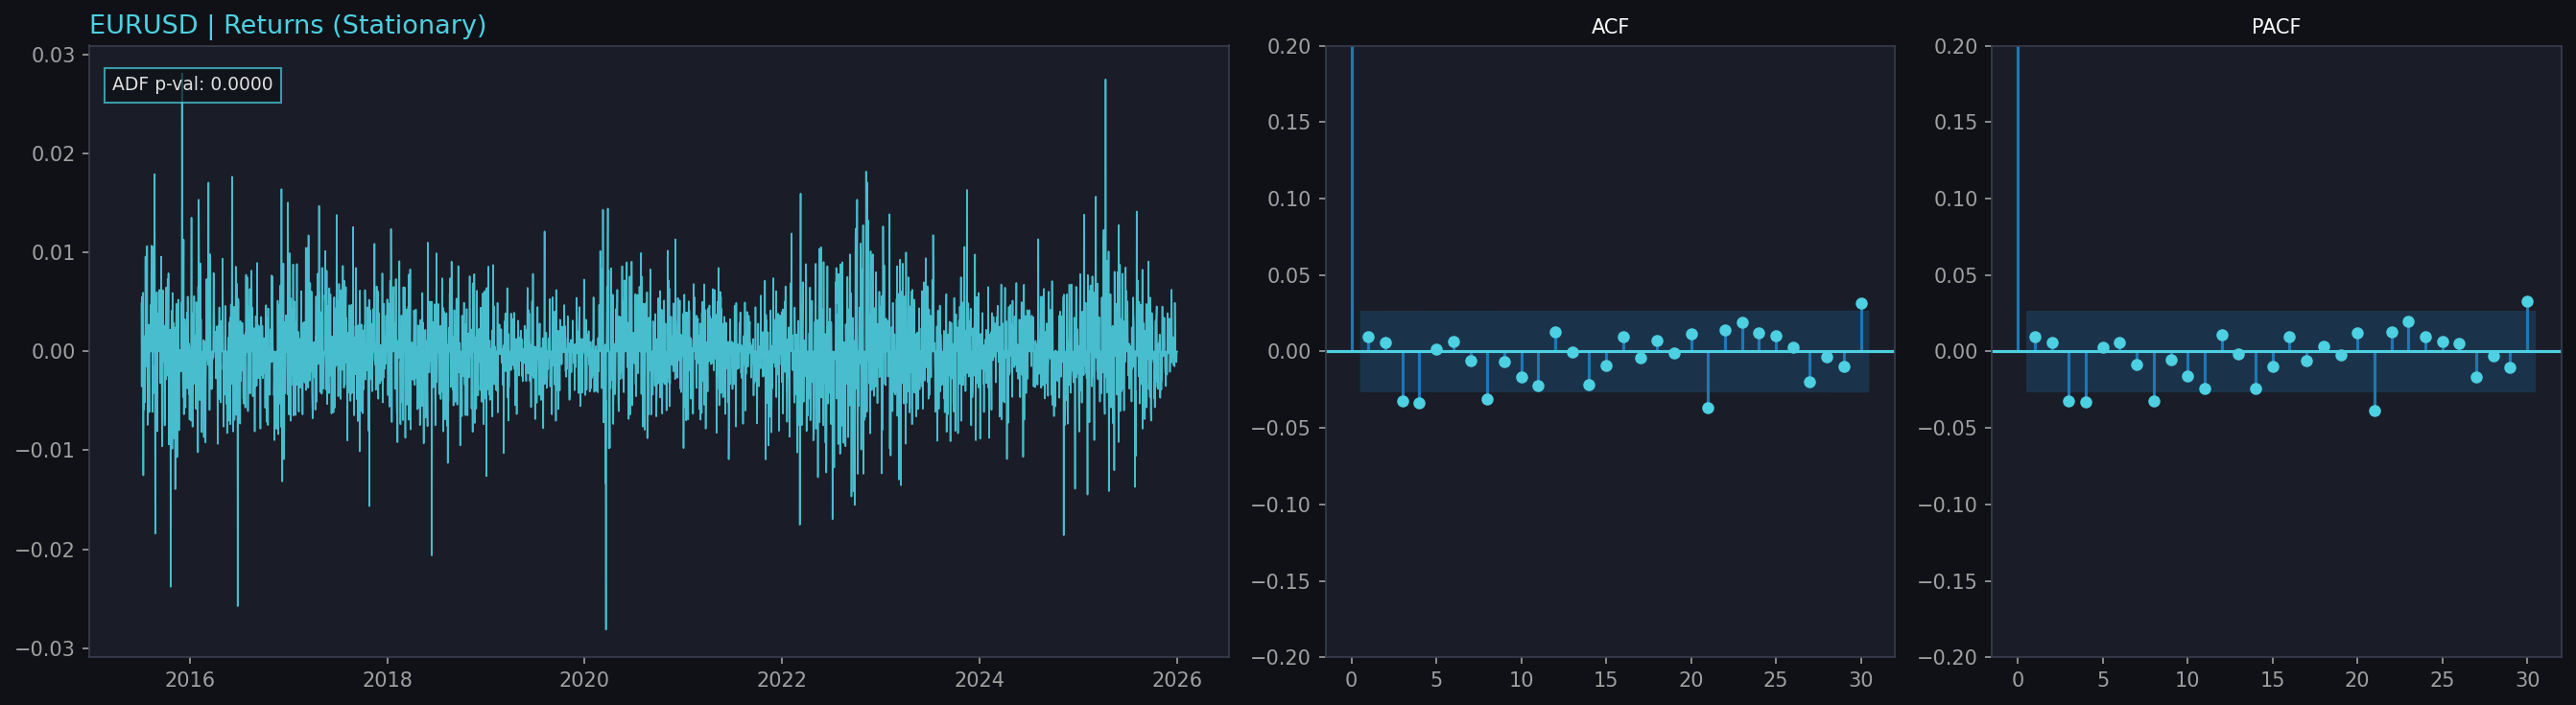

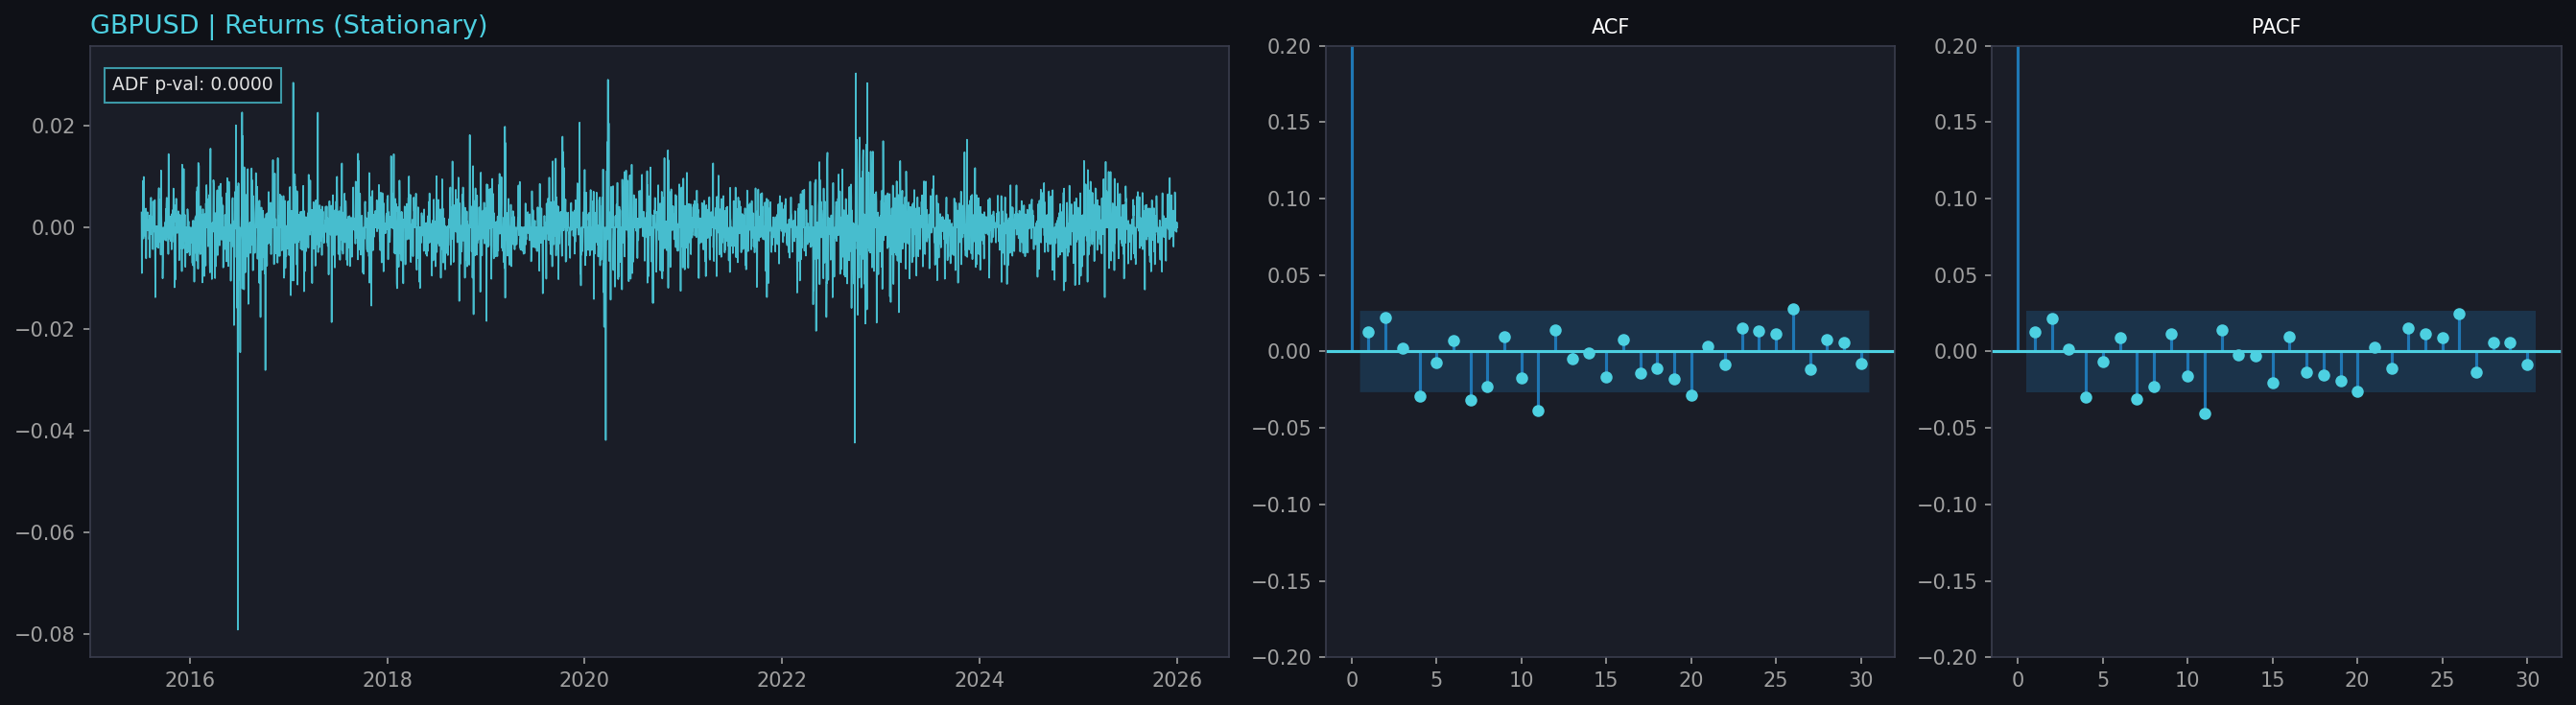

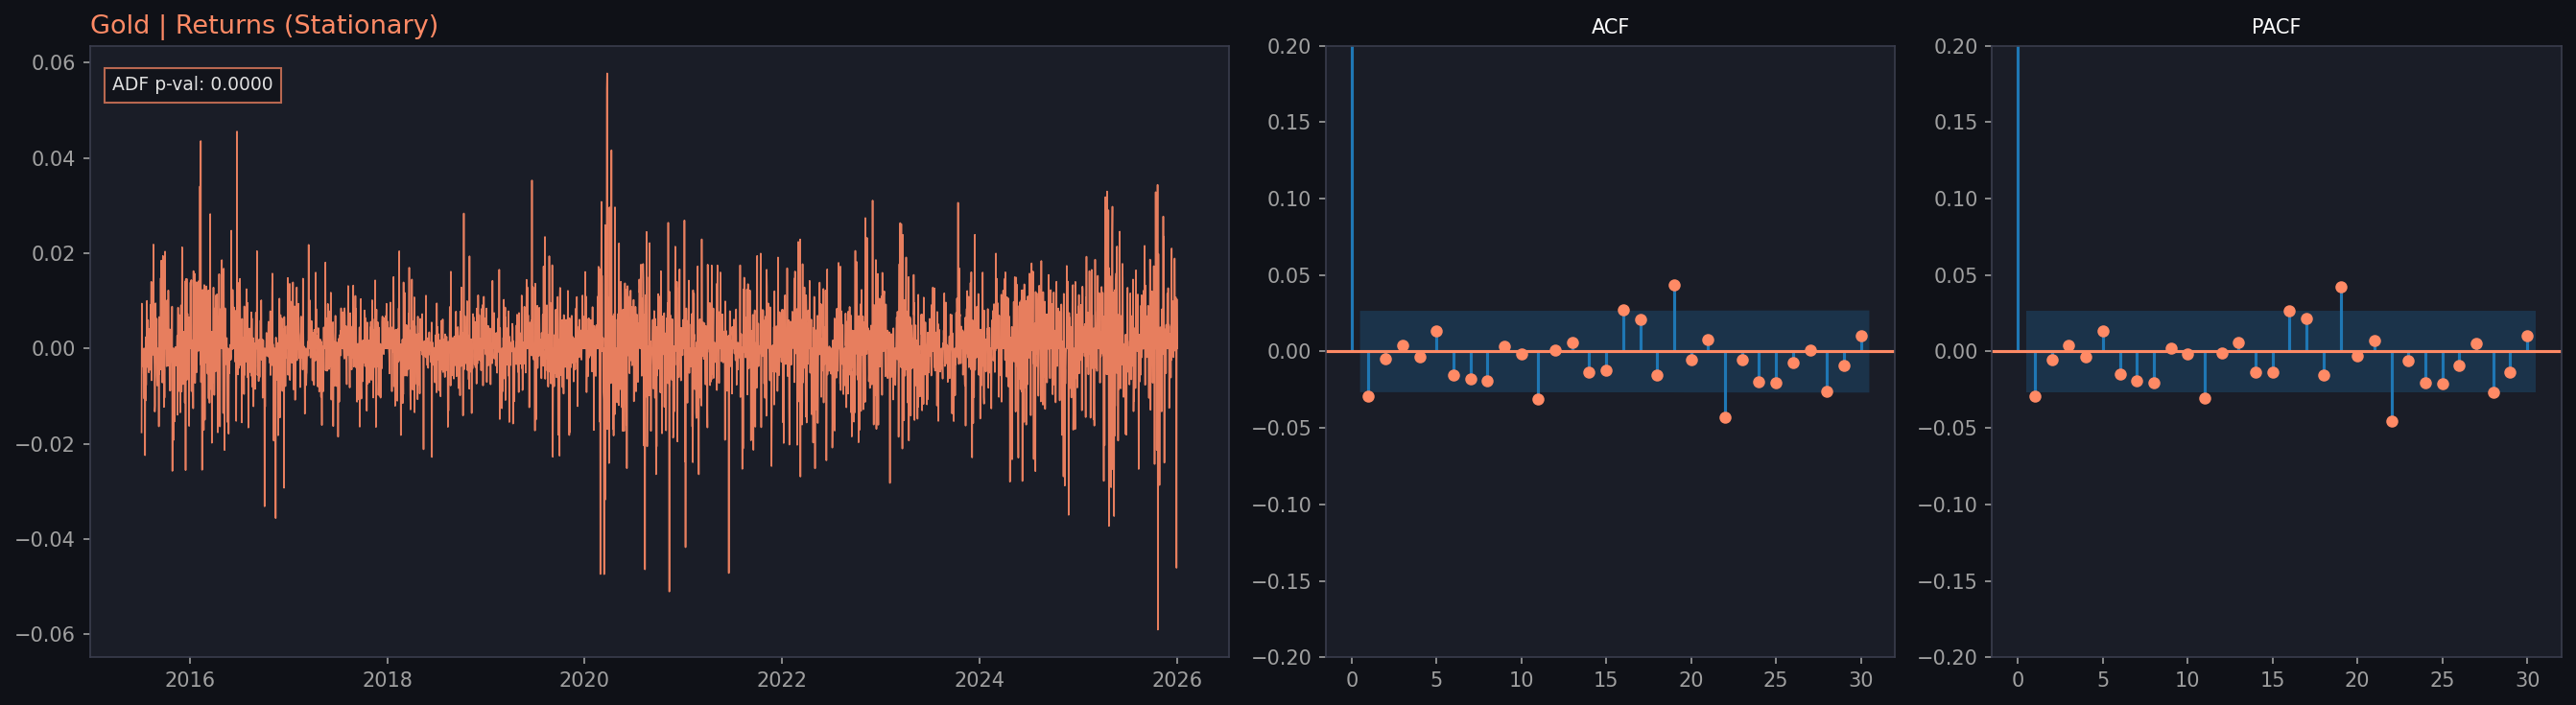

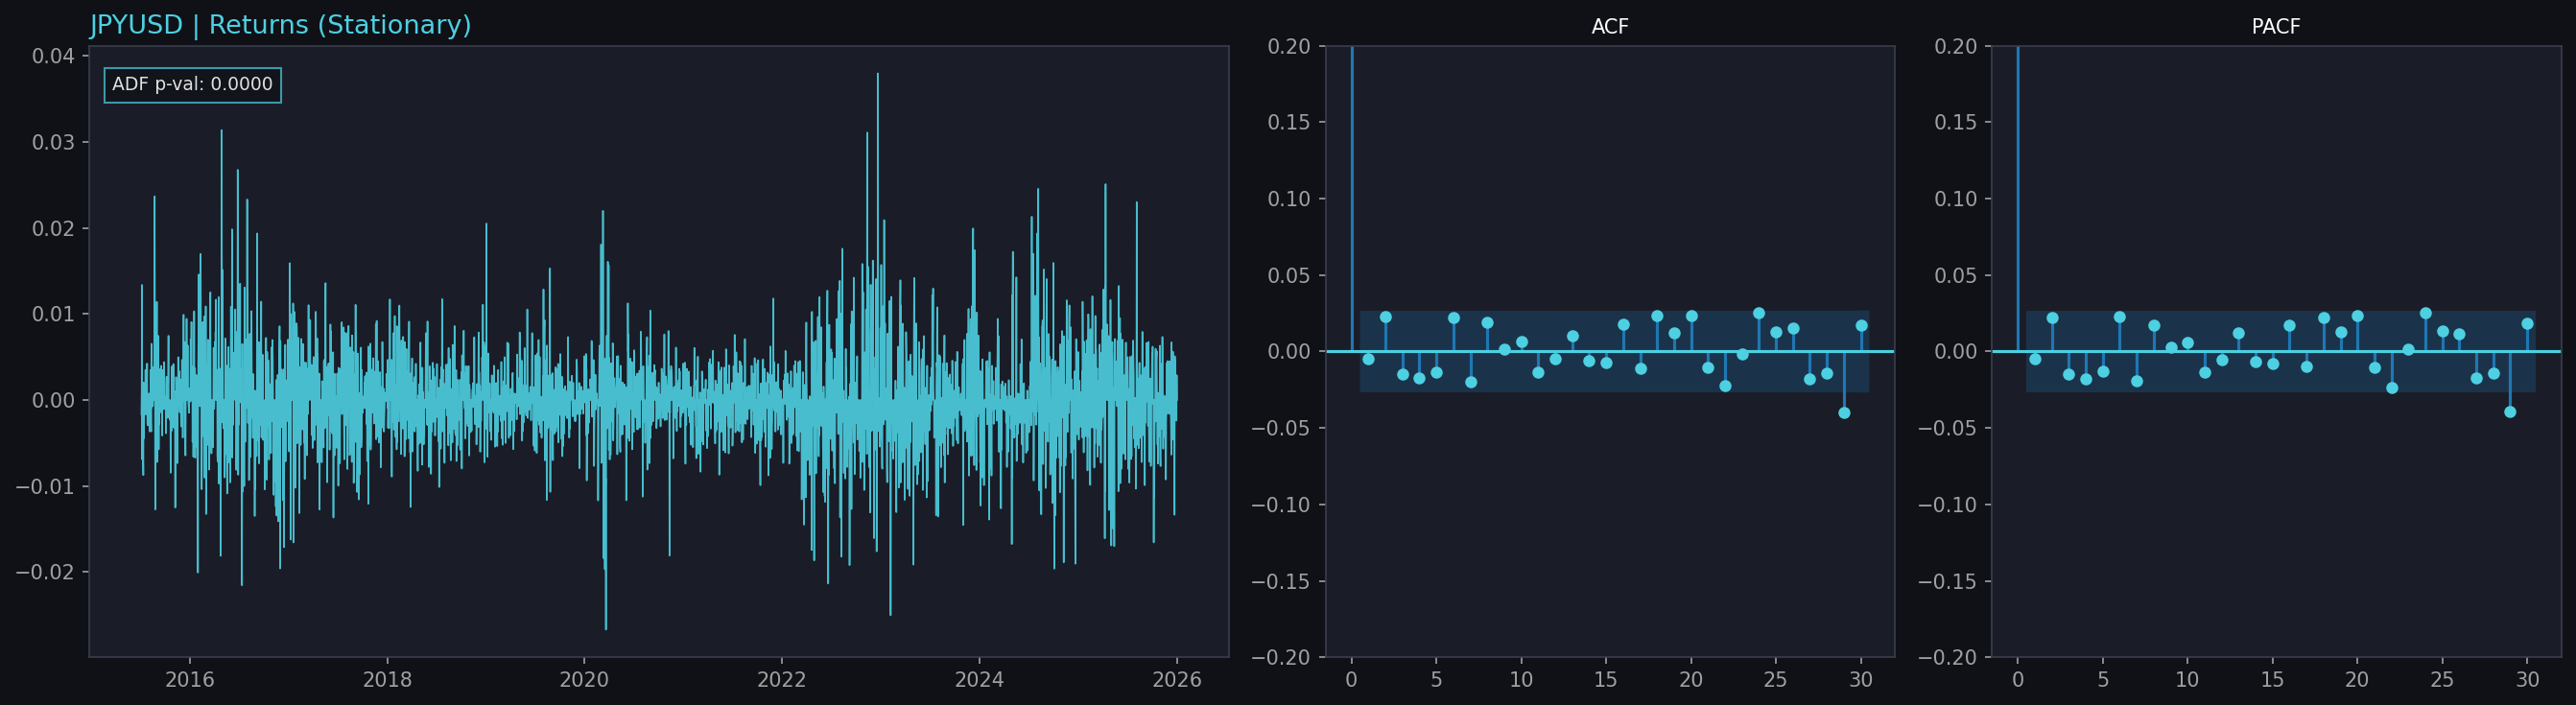

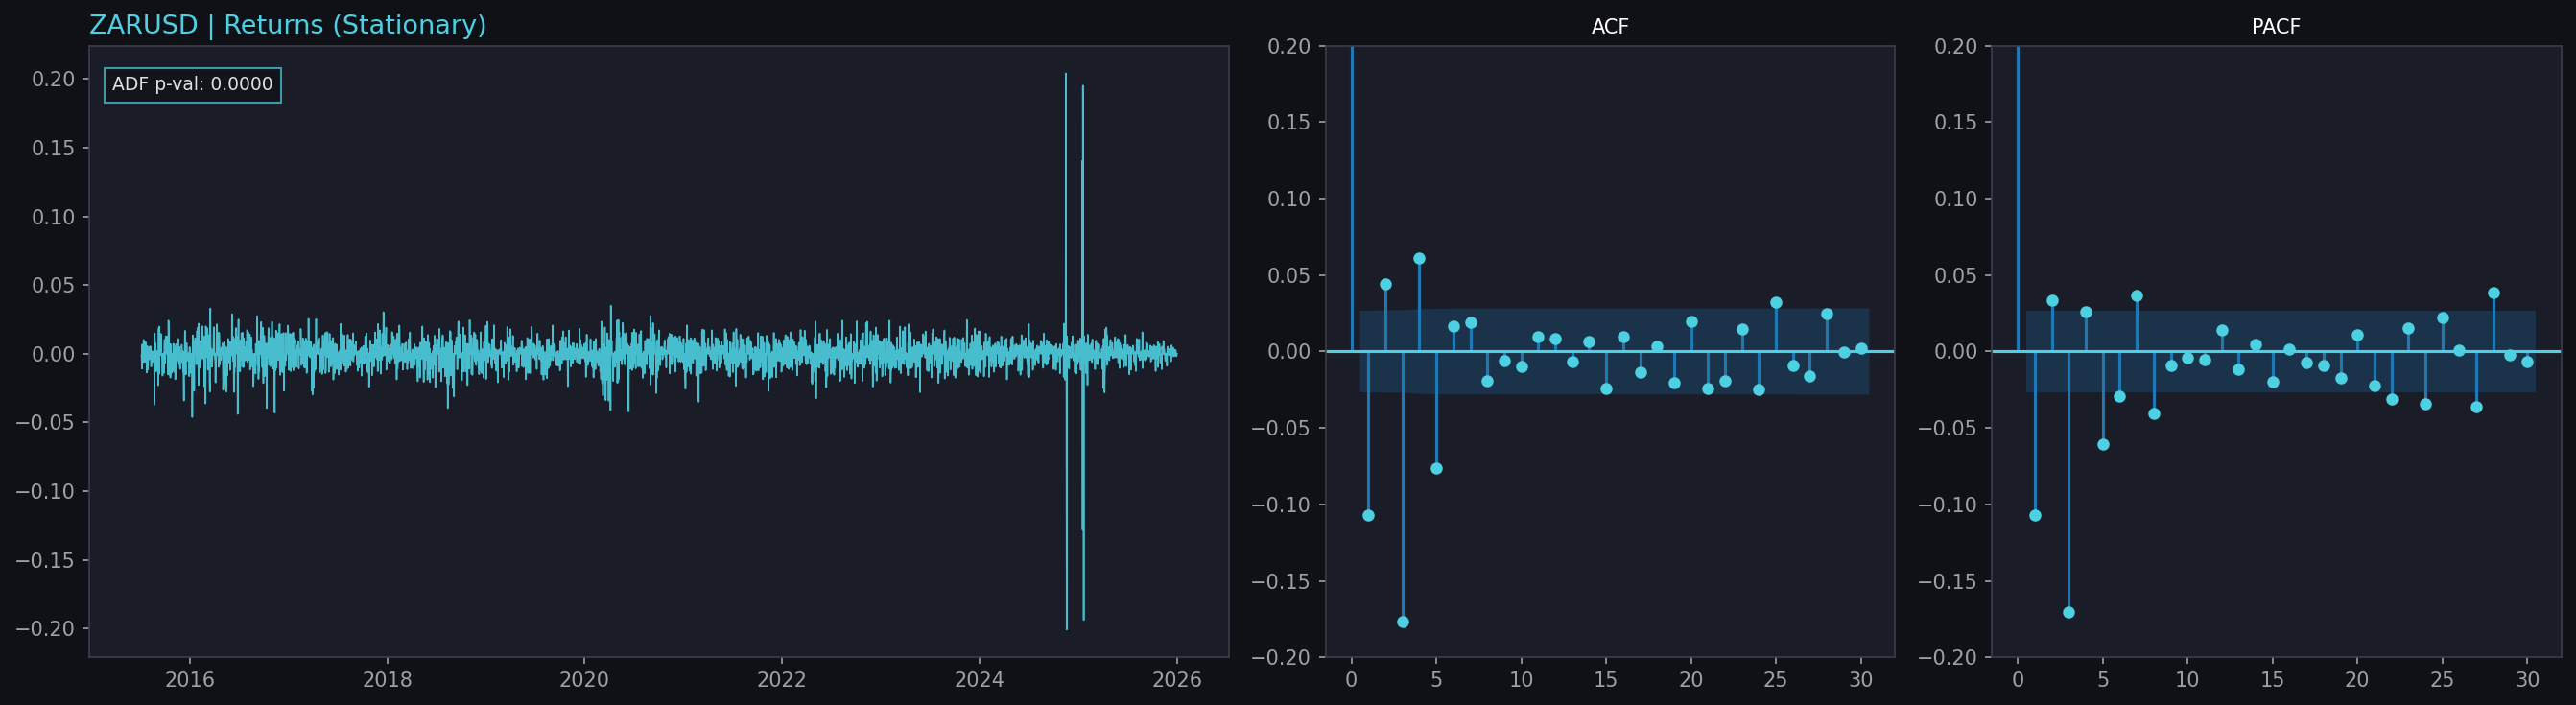

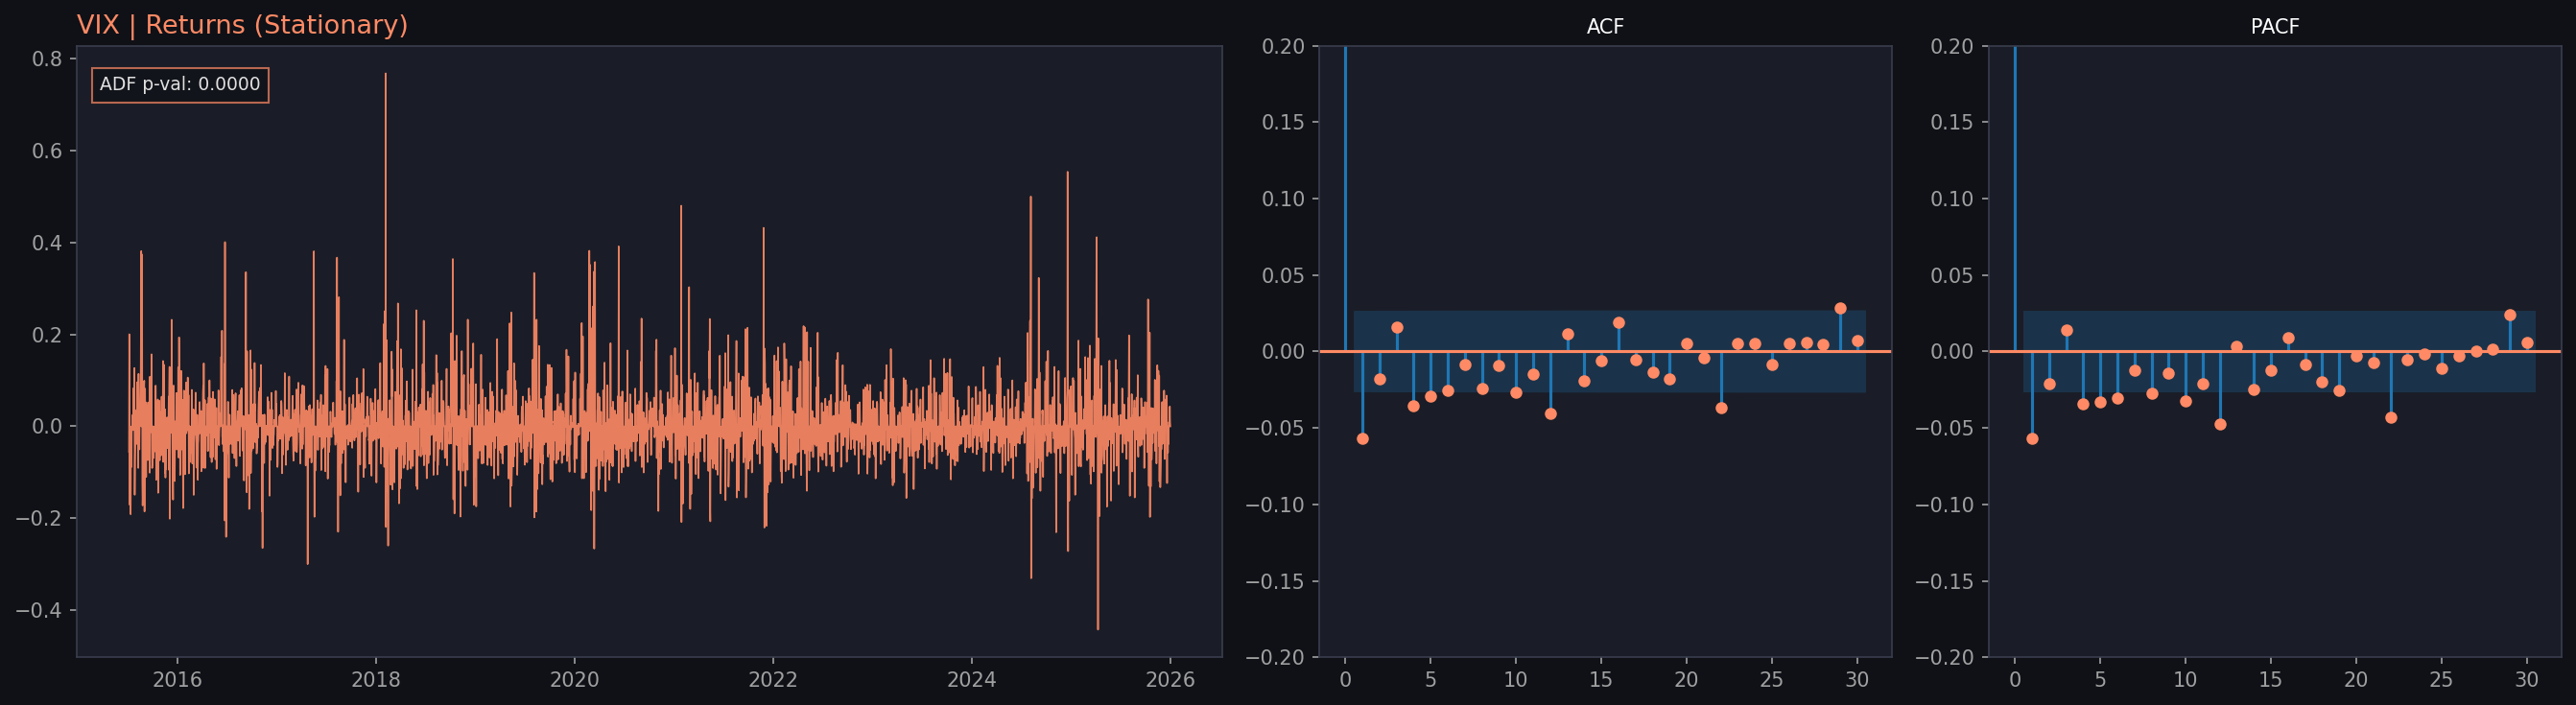

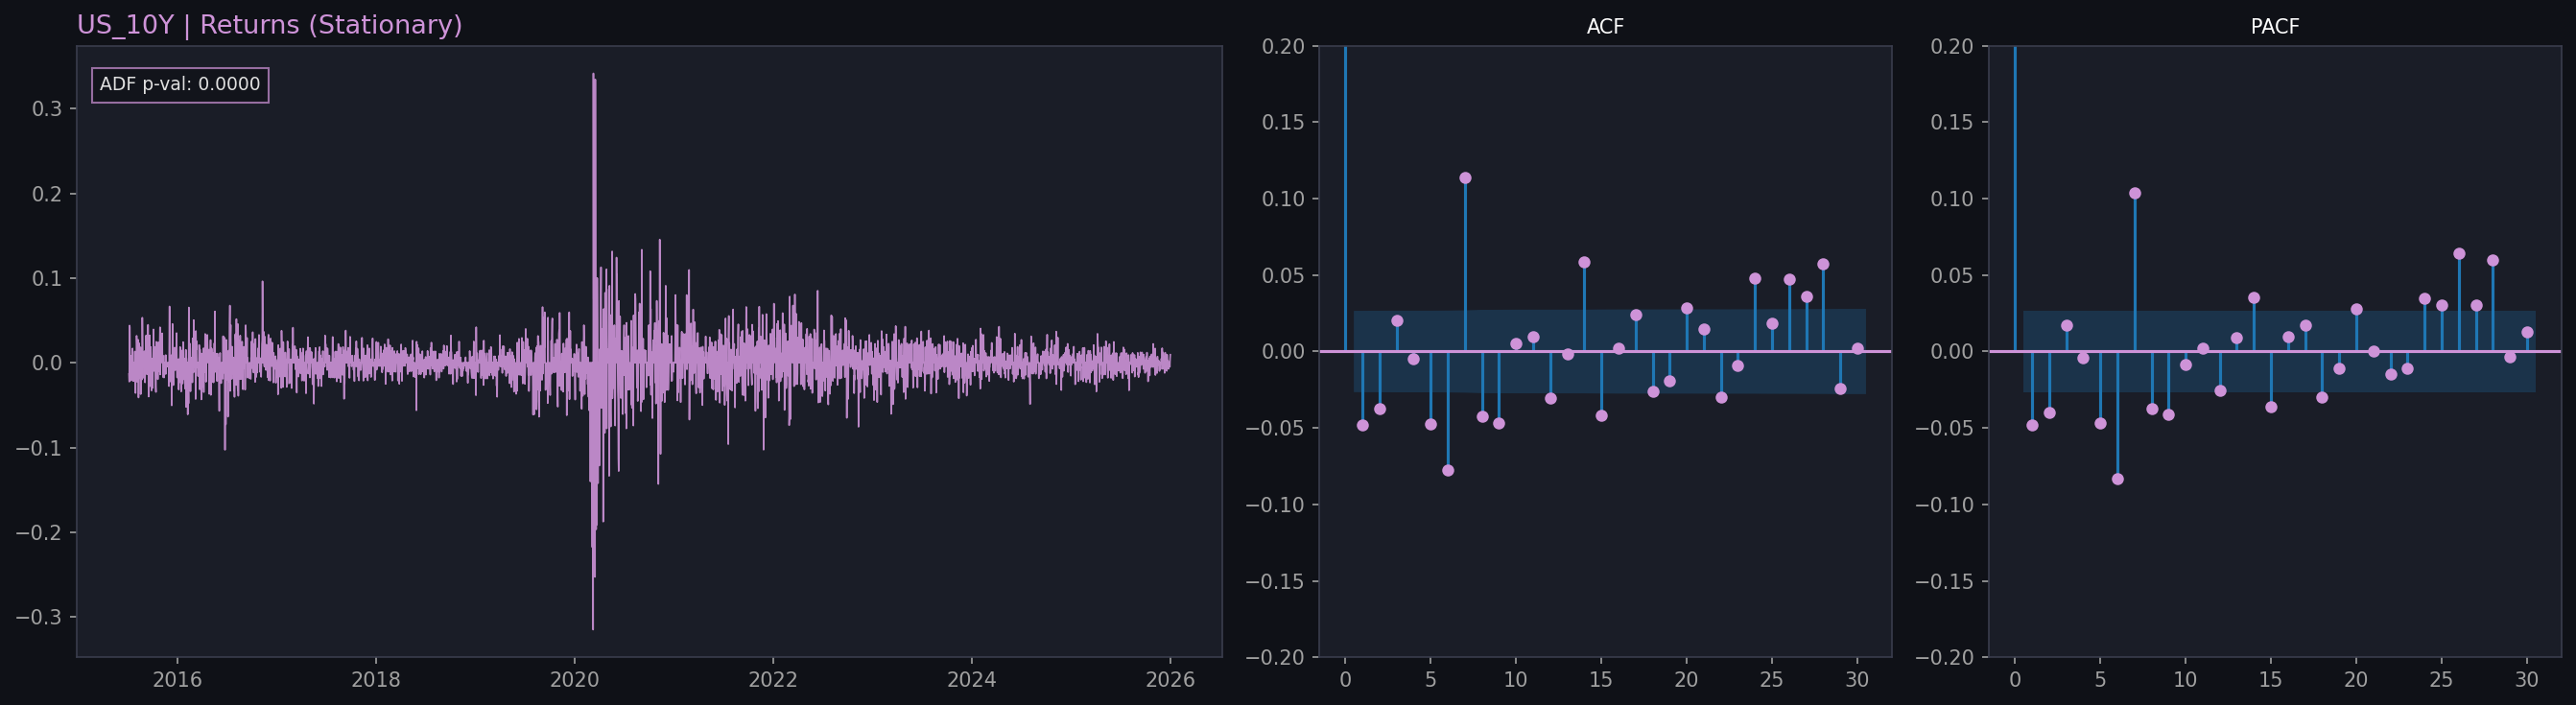

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


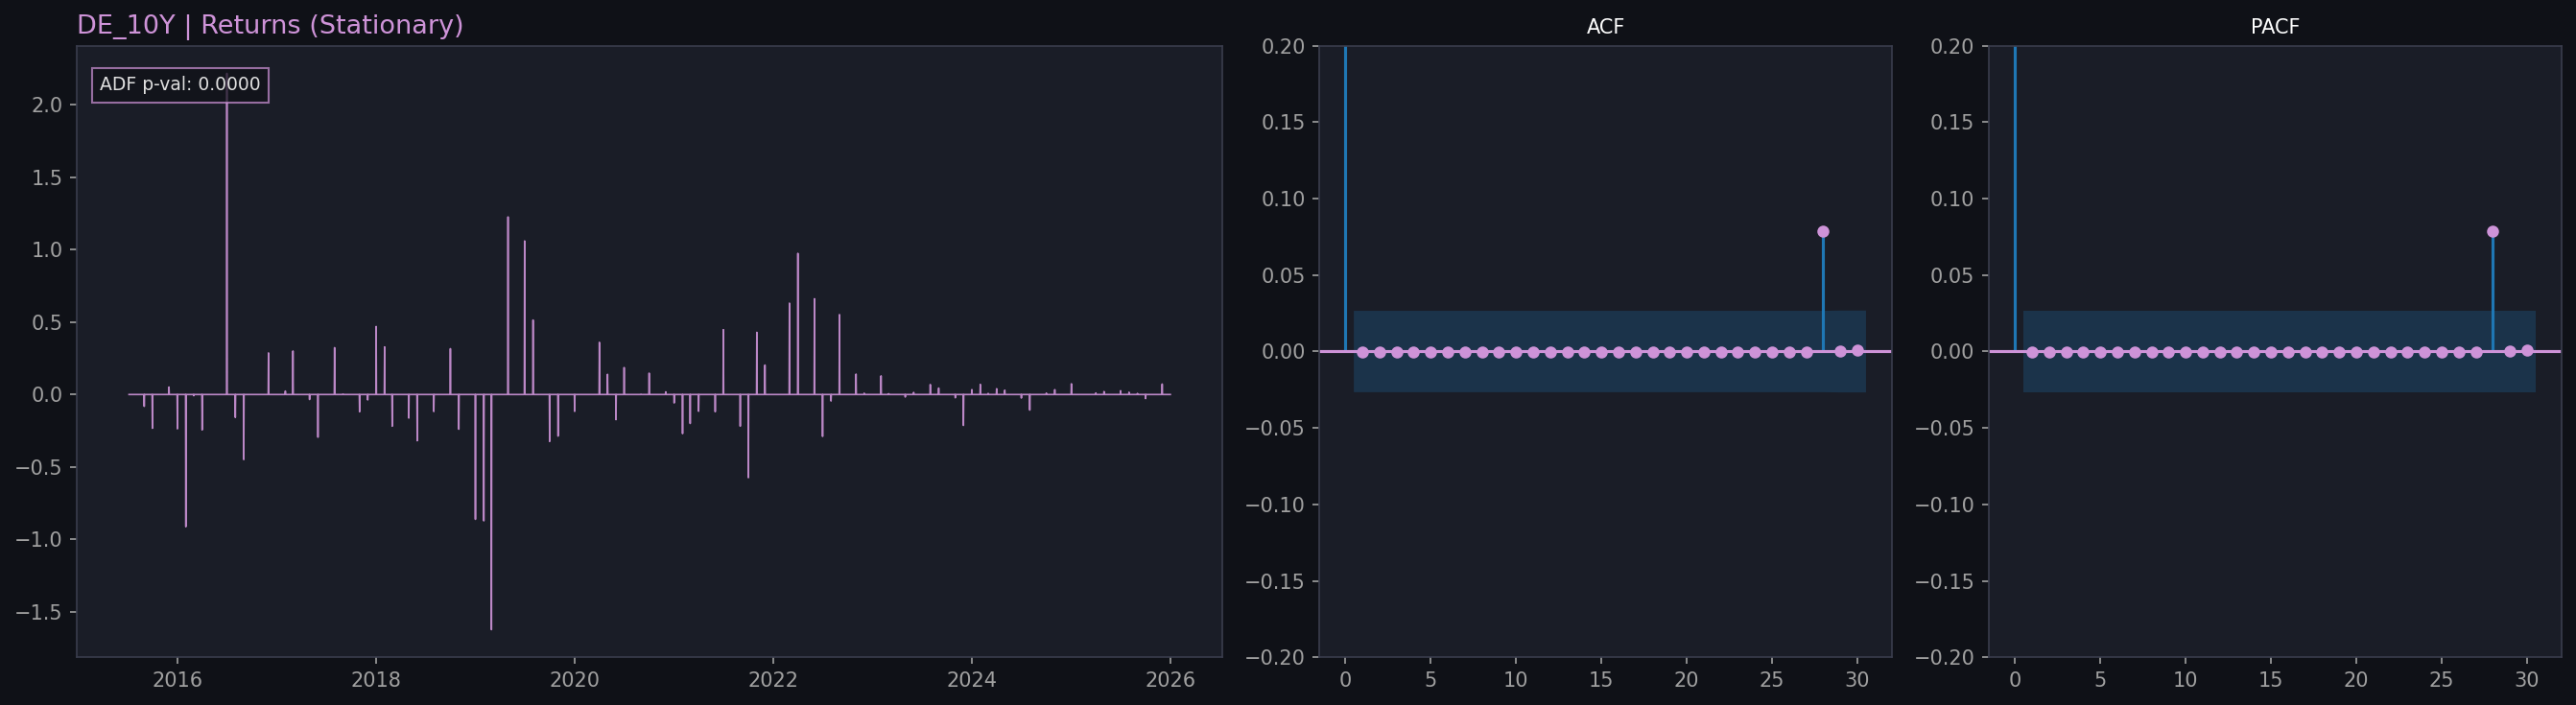

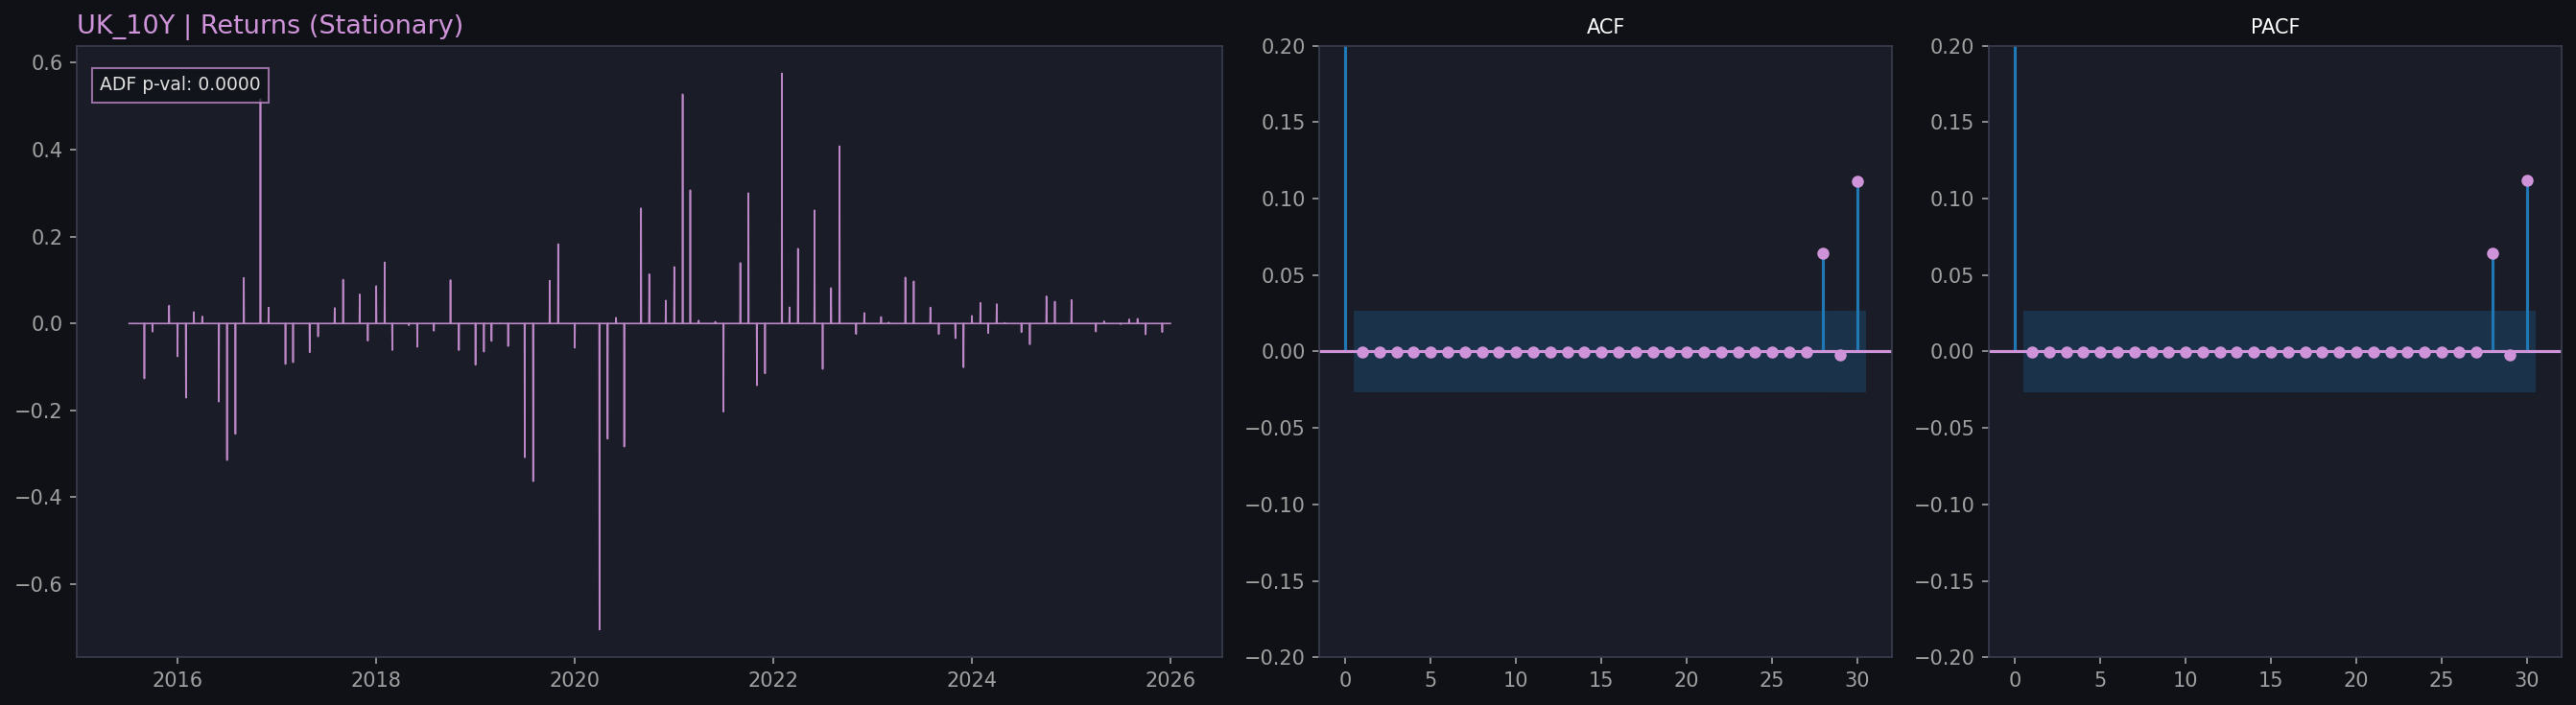

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Skipping JP_10Y due to error: exog contains inf or nans


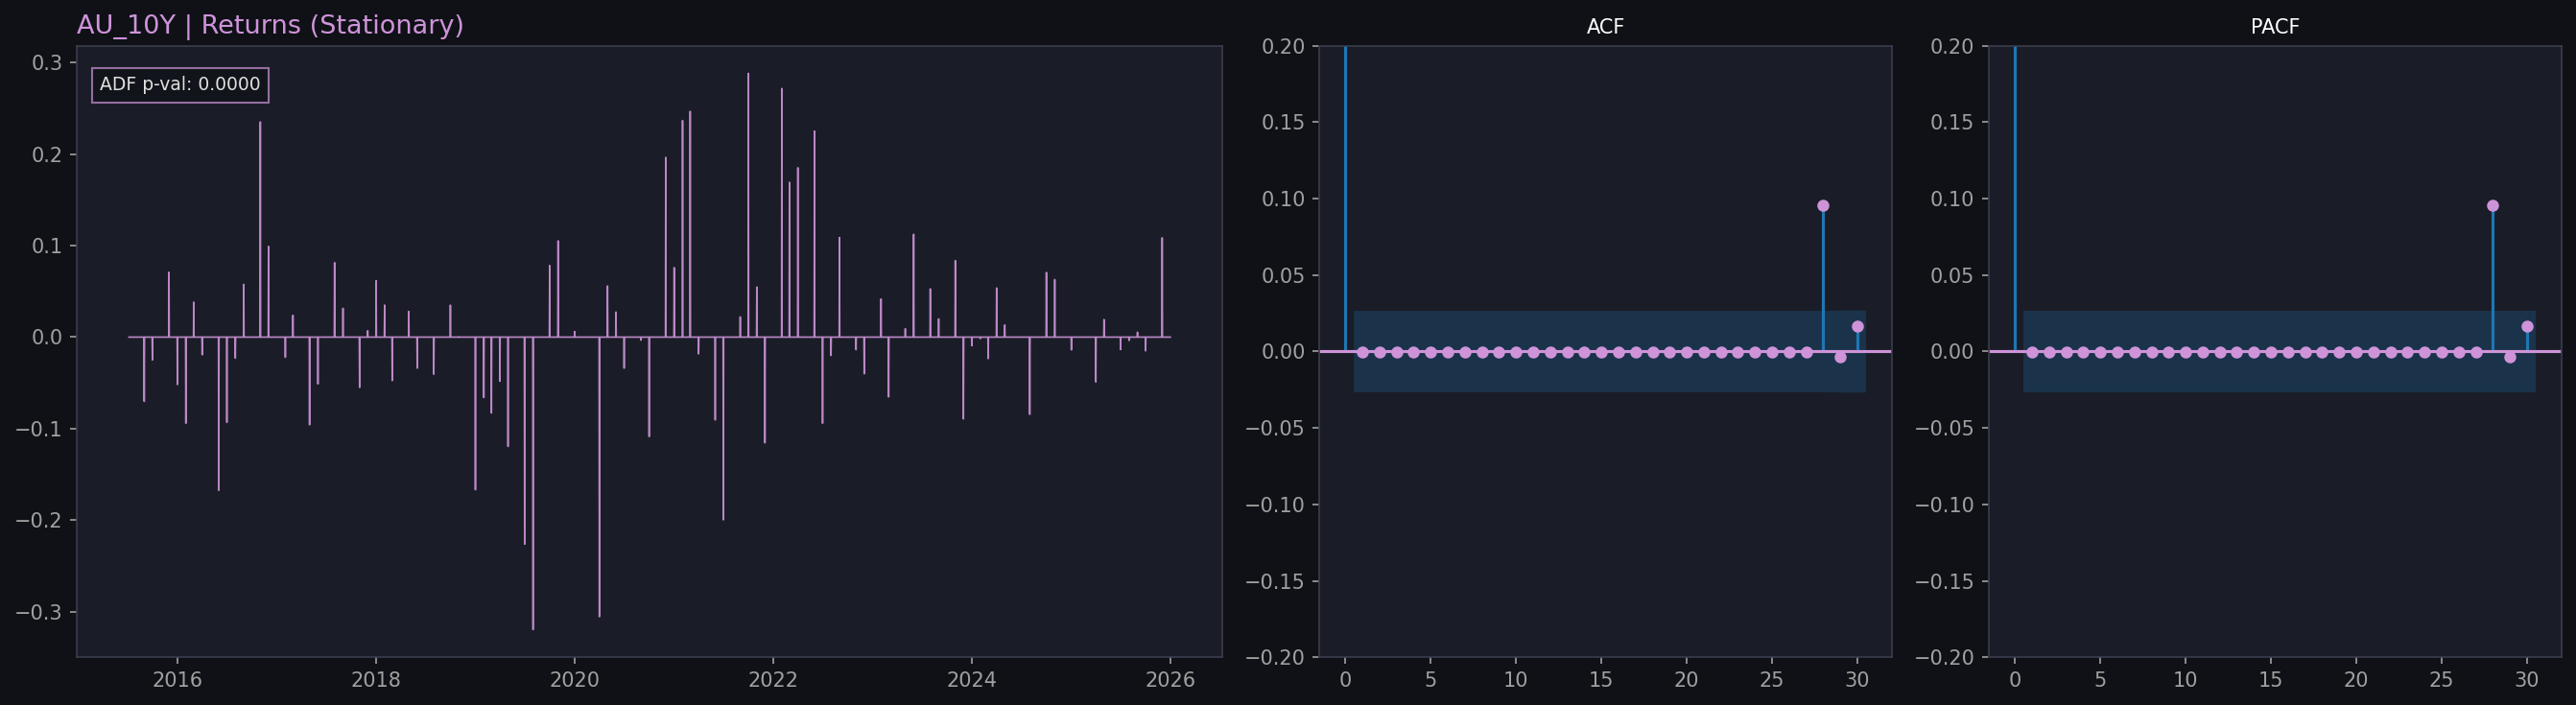

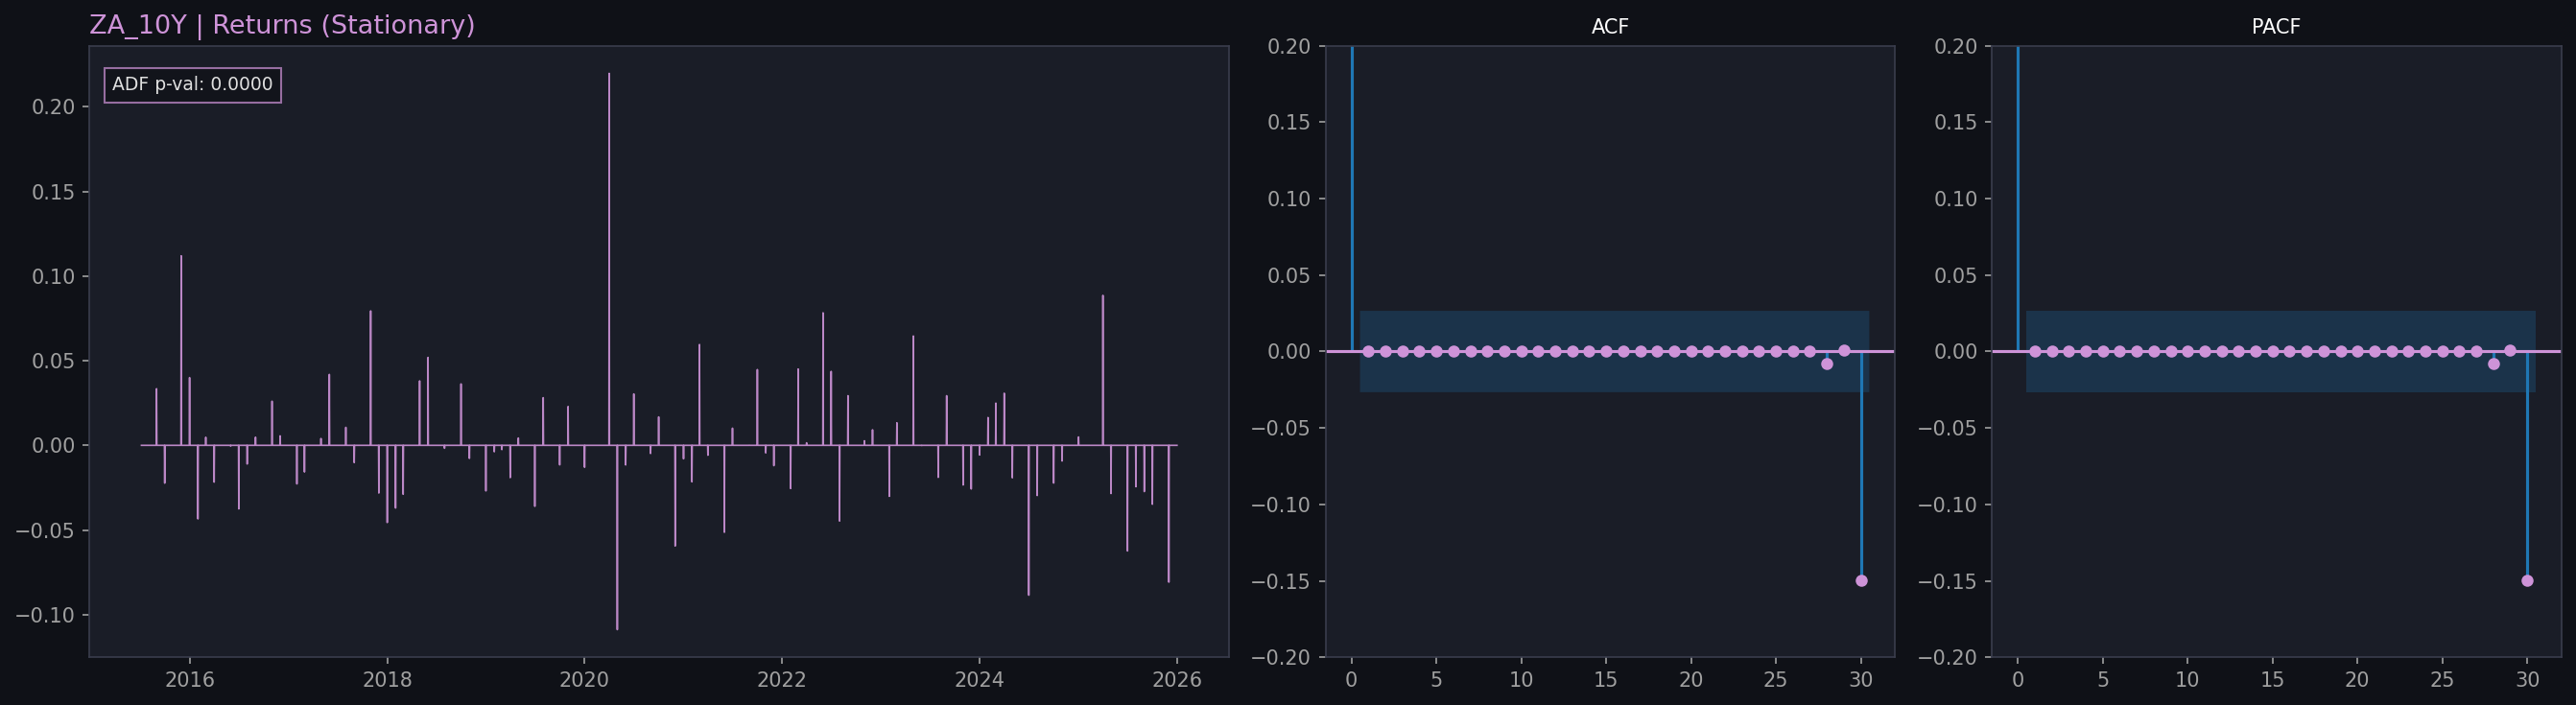

/tmp/ipykernel_2335/3119176643.py:65: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(summary_df.style.applymap(


,p-val,Result
Asset,,
SP500,0.000000,Stationary
BOVESPA,0.000000,Stationary
EUROSTOXX50,0.000000,Stationary
FTSE100,0.000000,Stationary
JSE40,0.000000,Stationary
NIKKEI225,0.000000,Stationary
ASX50,0.000000,Stationary
AUDJPY,0.000000,Stationary
AUDUSD,0.000000,Stationary


In [13]:
results_list = []

# ─── Revised individual loop to catch all assets ─────────────────────────────
for col in all_assets.columns:
    # Determine color based on column name or group
    if col in ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50']:
        # Map specific index names to your color palette keys
        color_key = 'Ibovespa' if col == 'BOVESPA' else ('EUROSTOXX' if col == 'EUROSTOXX50' else col)
        color = INDEX_COLORS.get(color_key, '#4fc3f7')
    elif '10Y' in col:
        color = INDEX_COLORS['Yields']
    elif any(fx in col for fx in ['USD', 'EUR', 'GBP']):
        color = INDEX_COLORS['FX']
    else:
        color = INDEX_COLORS['Risk']

    # Slice a single-column DataFrame to keep the structure compatible with your function
    asset_df = all_assets[[col]]

    # Define a clean version of the function logic to avoid the AttributeError
    def run_stationarity_plots_fixed(df, name, color):
        # Calculate individual Log-Returns
        returns = np.log(df / df.shift(1)).dropna().iloc[:, 0]

        # ADF Test
        adf_res = adfuller(returns)
        p_val = adf_res[1]
        status = "Stationary" if p_val < 0.05 else "Non-Stationary"

        fig = plt.figure(figsize=(18, 5))
        gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1])

        # 1. Return Plot
        ax0 = fig.add_subplot(gs[0])
        ax0.plot(returns, color=color, linewidth=0.8, alpha=0.9)
        ax0.set_title(f'{name} | Returns ({status})', color=color, loc='left')
        ax0.text(0.02, 0.95, f'ADF p-val: {p_val:.4f}', transform=ax0.transAxes,
                 fontsize=9, verticalalignment='top', bbox=dict(facecolor='#0f1117', edgecolor=color, alpha=0.7))

        # 2. ACF Plot - Removed 'vlines_kw' to fix AttributeError
        ax1 = fig.add_subplot(gs[1])
        plot_acf(returns, ax=ax1, lags=30, color=color, alpha=0.1)
        ax1.set_title('ACF', fontsize=10)
        ax1.set_ylim(-0.2, 0.2)

        # 3. PACF Plot - Removed 'vlines_kw' to fix AttributeError
        ax2 = fig.add_subplot(gs[2])
        plot_pacf(returns, ax=ax2, lags=30, color=color, alpha=0.1)
        ax2.set_title('PACF', fontsize=10)
        ax2.set_ylim(-0.2, 0.2)

        plt.tight_layout()
        plt.show()
        return {'Asset': name, 'p-val': p_val, 'Result': status}

    # Execute
    try:
        res = run_stationarity_plots_fixed(asset_df, col, color)
        results_list.append(res)
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")

# Summary Table will now include every individual asset
summary_df = pd.DataFrame(results_list).set_index('Asset')
display(summary_df.style.applymap(
    lambda x: 'color: #81c784' if x == 'Stationary' else 'color: #f06292', subset=['Result']
))